# Homework 2

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns

import jax
import jax.numpy as jnp
from jax import random

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

np.random.seed(42)
numpyro.set_host_device_count(2)

HDI_PROB = 0.89
MASTER_KEY = random.PRNGKey(42)

In [2]:
# ------------------------------
# Shared helper functions
# ------------------------------
def run_mcmc(model, rng_key, num_warmup=1000, num_samples=2000, num_chains=4, nuts_kwargs={}, **model_kwargs):
    """Run NumPyro NUTS and return (mcmc, arviz_idata, posterior_samples)."""
    kernel = NUTS(model, **nuts_kwargs)
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        progress_bar=False,
    )
    mcmc.run(rng_key, **model_kwargs)
    samples = mcmc.get_samples()
    idata = az.from_numpyro(mcmc)
    return mcmc, idata, samples


def count_divergences(idata):
    """Count total HMC divergences from an ArviZ InferenceData object."""
    if not hasattr(idata, "sample_stats") or "diverging" not in idata.sample_stats:
        return 0
    return int(np.asarray(idata.sample_stats["diverging"]).sum())


def plot_posteriors(params, title=None, ref_values=None, xlabels=None, ncols=2, hdi_prob=None):
    ref_values = ref_values or {}
    xlabels = xlabels or {}
    if hdi_prob is None:
        hdi_prob = HDI_PROB

    names = list(params.keys())
    n = len(names)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, name in enumerate(names):
        ax = axes[i]
        values = np.asarray(params[name]).reshape(-1)

        ax.hist(values, bins=35, density=True, alpha=0.6, color="tab:blue")

        mean_val = values.mean()
        hdi_low, hdi_high = np.asarray(az.hdi(values, hdi_prob=hdi_prob))

        ax.axvline(
            mean_val,
            color="black",
            linestyle="-",
            linewidth=2,
            label=f"Mean (Calculated)={mean_val:.3f}",
        )
        ax.axvline(
            hdi_low,
            color="red",
            linestyle=":",
            linewidth=2,
            label=f"{int(hdi_prob * 100)}% HDI [{hdi_low:.3f}, {hdi_high:.3f}]",
        )
        ax.axvline(
            hdi_high,
            color="red",
            linestyle=":",
            linewidth=2,
        )

        if name in ref_values:
            ax.axvline(
                ref_values[name],
                color="limegreen",
                linestyle=":",
                linewidth=3,
                label=f"True Value (Given)={ref_values[name]:.3f}",
            )

        all_x = [values.min(), values.max(), hdi_low, hdi_high, mean_val]
        if name in ref_values:
            all_x.append(ref_values[name])

        x_min, x_max = min(all_x), max(all_x)
        x_pad = 0.05 * (x_max - x_min)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

        ax.set_xlabel(xlabels.get(name, name))
        ax.set_ylabel("Density")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper left", fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    if title:
        fig.suptitle(title, y=1.02)

    fig.tight_layout()
    plt.show()

In [3]:
def print_fit_report(model_name, idata, summary_df=None, hdi_prob=None):
    """Print a compact convergence/fit report and optionally display a summary table."""
    if hdi_prob is None:
        hdi_prob = HDI_PROB

    divs = count_divergences(idata)
    print(f"\n=== {model_name} ===")
    print(f"Divergences: {divs}")

    if hasattr(idata, "sample_stats") and "lp" in idata.sample_stats:
        lp = np.asarray(idata.sample_stats["lp"])
        print(f"Mean log posterior (lp): {lp.mean():.3f}")

    if summary_df is not None:
        display(summary_df)
    else:
        # Fall back to a generic ArviZ summary if caller does not pass one.
        try:
            print(az.summary(idata, hdi_prob=hdi_prob))
        except Exception:
            pass

In [4]:
# ------------------------------
# Load all datasets once
# ------------------------------
q1 = pd.read_csv("q1_data.csv")
q2 = pd.read_csv("q2_data.csv")
q3 = pd.read_csv("q3_data.csv")
q4 = pd.read_csv("q4_data.csv")
q5 = pd.read_csv("q5_data.csv")

## Q1. Confounded Agricultural Intervention

In [5]:
q1.head()

,Z,X,M,Y,W
0,0.427164,0.048981,-1.616623,-1.080636,-1.187257
1,2.588570,1.548663,-0.864462,1.839977,0.888500
2,0.652893,3.556580,1.154609,5.403191,1.941977
3,0.505840,-1.514590,-1.919362,-2.522395,-2.114191
4,-0.475951,-2.347255,-2.019438,-3.576371,-3.111159


In [6]:
q1.describe()


,Z,X,M,Y,W
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.026830,0.078689,0.111968,0.169872,-0.028154
std,1.002806,1.337936,1.241761,2.085450,1.738522
min,-3.283915,-3.505449,-3.469626,-5.463430,-4.613266
25%,-0.681372,-0.851144,-0.655607,-1.352101,-1.161519
50%,-0.013378,0.048786,0.154827,0.249624,-0.049852
75%,0.705202,1.109455,0.928687,1.618148,1.167464
max,2.645353,3.694556,3.795538,5.959570,5.032091


In [7]:
q1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Z       300 non-null    float64
 1   X       300 non-null    float64
 2   M       300 non-null    float64
 3   Y       300 non-null    float64
 4   W       300 non-null    float64
dtypes: float64(5)
memory usage: 11.8 KB


In [8]:
Z = jnp.asarray(q1["Z"].values)
X = jnp.asarray(q1["X"].values)
M = jnp.asarray(q1["M"].values)
Y = jnp.asarray(q1["Y"].values)
W = jnp.asarray(q1["W"].values)

In [9]:
# Naive Model

def q1_naive_model(x, y=None): 
    alpha = numpyro.sample("alpha", dist.Normal(0, 2)) # Intercept 
    beta_naive = numpyro.sample("beta_naive", dist.Normal(0, 2)) 
    sigma = 0.5 # Its given that 𝜖 ∼ 𝒩 (0, 0.5^2) 
    mu = alpha + beta_naive * x
    numpyro.sample("Y_obs", dist.Normal(mu, sigma), obs=y)

In [10]:
# Display MCMC diagnostics
naive_mcmc, naive_idata, naive_samp = run_mcmc(q1_naive_model, MASTER_KEY, x=X, y=Y)
az.summary(naive_idata, var_names=["alpha", "beta_naive"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.072,0.029,0.024,0.117,0.0,0.0,6658.0,5218.0,1.0
beta_naive,1.238,0.021,1.203,1.271,0.0,0.0,6612.0,5123.0,1.0


In [11]:
# Divergences 
print(f"Divergences: {count_divergences(naive_idata)}")

Divergences: 0


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_naive'}>,
        <Axes: title={'center': 'beta_naive'}>]], dtype=object)

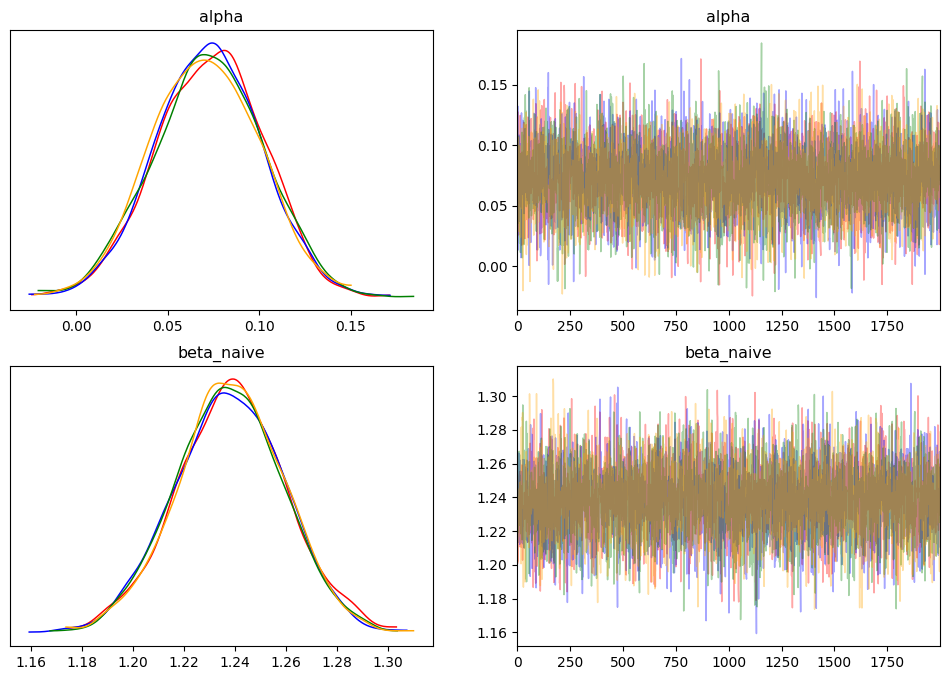

In [12]:
# Plot divergences
az.plot_trace(
        naive_idata,
        var_names=["~sample_stats"],
        divergences="top",
        compact=True,
        chain_prop={'color': ['red', 'blue', 'green', 'orange']},
        figsize=(12, 8)
    )

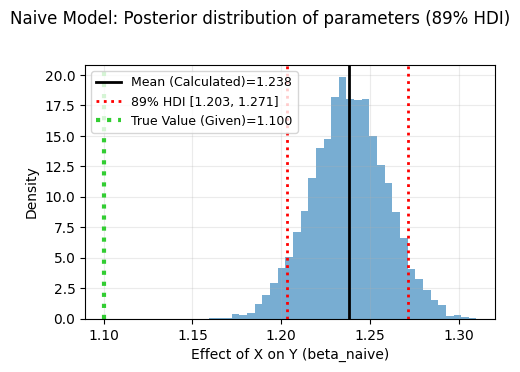

In [13]:
# Plot the posterior distribution of the parameters
plot_posteriors(
    {
        "beta_naive": naive_samp["beta_naive"],
    },
    title="Naive Model: Posterior distribution of parameters (89% HDI)",
    ref_values={"beta_naive": 1.1},
    xlabels={"beta_naive": "Effect of X on Y (beta_naive)"},
    ncols=2,
)

# Calculate the total effect using the naive model
naive_beta = np.asarray(naive_samp["beta_naive"])

In [14]:
def q1_joint_iv_model(z, x, y):
    gamma0 = numpyro.sample("gamma0", dist.Normal(0, 2))
    gammaZ = numpyro.sample("gammaZ", dist.Normal(0, 2))
    alpha = numpyro.sample("alpha", dist.Normal(0, 2))
    beta_total = numpyro.sample("beta_total", dist.Normal(0, 2))
    eta_cf = numpyro.sample("eta_cf", dist.Normal(0, 2))

    # Structural noise scales from the Q1 DGP assumptions.
    sigma_x = 0.5
    sigma_y = 0.5

    # First stage: X depends on instrument Z.
    mu_x = gamma0 + gammaZ * z
    numpyro.sample("X_obs", dist.Normal(mu_x, sigma_x), obs=x)

    # Control-function residual captures endogeneity in X.
    v = x - mu_x

    # Structural outcome equation: Y depends on realized X.
    mu_y = alpha + beta_total * x + eta_cf * v
    numpyro.sample("Y_obs", dist.Normal(mu_y, sigma_y), obs=y)

    # Keep reduced-form slope available for reporting.
    numpyro.deterministic("piZ", beta_total * gammaZ)

In [15]:
# Display MCMC diagnostics
iv_mcmc, iv_idata, iv_samp = run_mcmc(q1_joint_iv_model, MASTER_KEY, z=Z, x=X, y=Y)
az.summary(iv_idata, var_names=["alpha", "gamma0", "gammaZ", "beta_total", "eta_cf", "piZ"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.084,0.030,0.035,0.131,0.000,0.000,6928.0,5178.0,1.0
gamma0,0.060,0.029,0.013,0.105,0.000,0.000,6875.0,5507.0,1.0
gammaZ,0.704,0.028,0.659,0.750,0.000,0.000,7002.0,5831.0,1.0
beta_total,1.099,0.042,1.031,1.164,0.001,0.000,4140.0,4952.0,1.0
eta_cf,0.193,0.049,0.115,0.271,0.001,0.001,4045.0,4727.0,1.0
piZ,0.774,0.047,0.692,0.843,0.001,0.000,4766.0,5023.0,1.0


In [16]:
# Divergences 
print(f"Divergences: {count_divergences(iv_idata)}")

Divergences: 0


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta_total'}>,
        <Axes: title={'center': 'beta_total'}>],
       [<Axes: title={'center': 'eta_cf'}>,
        <Axes: title={'center': 'eta_cf'}>],
       [<Axes: title={'center': 'gamma0'}>,
        <Axes: title={'center': 'gamma0'}>],
       [<Axes: title={'center': 'gammaZ'}>,
        <Axes: title={'center': 'gammaZ'}>],
       [<Axes: title={'center': 'piZ'}>, <Axes: title={'center': 'piZ'}>]],
      dtype=object)

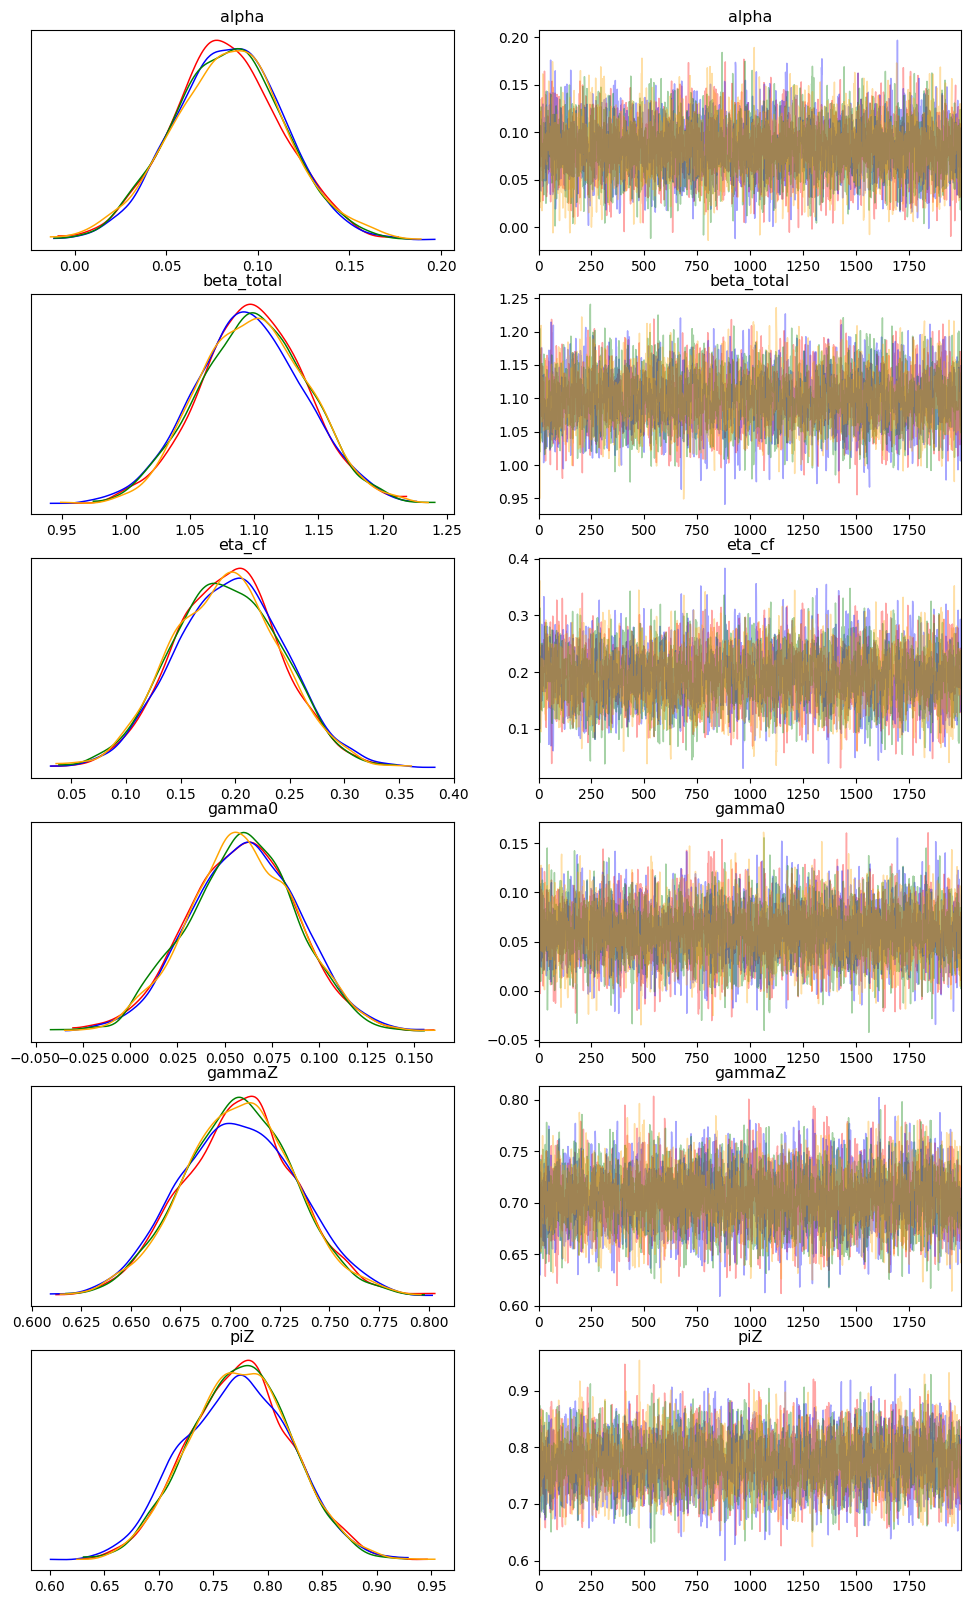

In [17]:
# Plot divergences
az.plot_trace(
        iv_idata,
        var_names=["~sample_stats"],
        divergences="top",
        compact=True,
        chain_prop={'color': ['red', 'blue', 'green', 'orange']},
        figsize=(12, 20)
    )

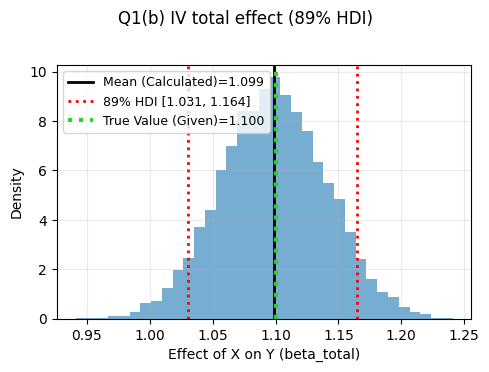

In [18]:
plot_posteriors(
    {
        "beta_total": iv_samp["beta_total"],
    },
    title="Q1(b) IV total effect (89% HDI)",
    ref_values={"beta_total": 1.1},
    xlabels={"beta_total": "Effect of X on Y (beta_total)"},
    ncols=2,
)

### Q1(c)

In [19]:
# X -> M

def q1_mediator_model(x, m=None):
    delta0 = numpyro.sample("delta0", dist.Normal(0, 2))
    delta = numpyro.sample("delta", dist.Normal(0, 2))
    sigma_m = 0.5
    mu_m = delta0 + delta * x
    numpyro.sample("M_obs", dist.Normal(mu_m, sigma_m), obs=m)

In [20]:
med_mcmc, med_idata, med_samp = run_mcmc(q1_mediator_model, MASTER_KEY, x=X, m=M)

In [21]:
az.summary(med_idata, var_names=["delta0", "delta"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta0,0.067,0.029,0.019,0.110,0.0,0.0,6119.0,4949.0,1.0
delta,0.581,0.022,0.548,0.618,0.0,0.0,6337.0,4957.0,1.0


In [22]:
# M -> Y

def q1_lambda_model(z, x, m, y=None):
    gamma0 = numpyro.sample("gamma0", dist.Normal(0, 2))
    gammaZ = numpyro.sample("gammaZ", dist.Normal(0, 2))
    beta0 = numpyro.sample("beta0", dist.Normal(0, 2))
    beta_x_given_m = numpyro.sample("beta_x_given_m", dist.Normal(0, 2))
    lambda_ = numpyro.sample("lambda", dist.Normal(0, 2))
    eta_cf = numpyro.sample("eta_cf", dist.Normal(0, 2))

    sigma_x = 0.5
    sigma_y = 0.5

    # Re-fit the first stage only to control for X endogeneity while estimating lambda.
    mu_x = gamma0 + gammaZ * z
    numpyro.sample("X_obs", dist.Normal(mu_x, sigma_x), obs=x)

    v = x - mu_x
    mu_y = beta0 + beta_x_given_m * x + lambda_ * m + eta_cf * v
    numpyro.sample("Y_obs", dist.Normal(mu_y, sigma_y), obs=y)

In [23]:
lambda_mcmc, lambda_idata, lambda_samp = run_mcmc(q1_lambda_model, MASTER_KEY, z=Z, x=X, m=M, y=Y)

In [24]:
az.summary(lambda_idata, var_names=["lambda", "beta_x_given_m", "eta_cf", "gamma0", "gammaZ"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda,0.518,0.031,0.469,0.565,0.000,0.000,6838.0,5631.0,1.0
beta_x_given_m,0.727,0.049,0.645,0.800,0.001,0.001,4612.0,5028.0,1.0
eta_cf,0.292,0.052,0.214,0.378,0.001,0.001,5023.0,5279.0,1.0
gamma0,0.060,0.029,0.012,0.103,0.000,0.000,6744.0,5958.0,1.0
gammaZ,0.704,0.029,0.658,0.750,0.000,0.000,6659.0,5569.0,1.0


array([[<Axes: title={'center': 'beta0'}>,
        <Axes: title={'center': 'beta0'}>],
       [<Axes: title={'center': 'beta_x_given_m'}>,
        <Axes: title={'center': 'beta_x_given_m'}>],
       [<Axes: title={'center': 'eta_cf'}>,
        <Axes: title={'center': 'eta_cf'}>],
       [<Axes: title={'center': 'gamma0'}>,
        <Axes: title={'center': 'gamma0'}>],
       [<Axes: title={'center': 'gammaZ'}>,
        <Axes: title={'center': 'gammaZ'}>],
       [<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>]], dtype=object)

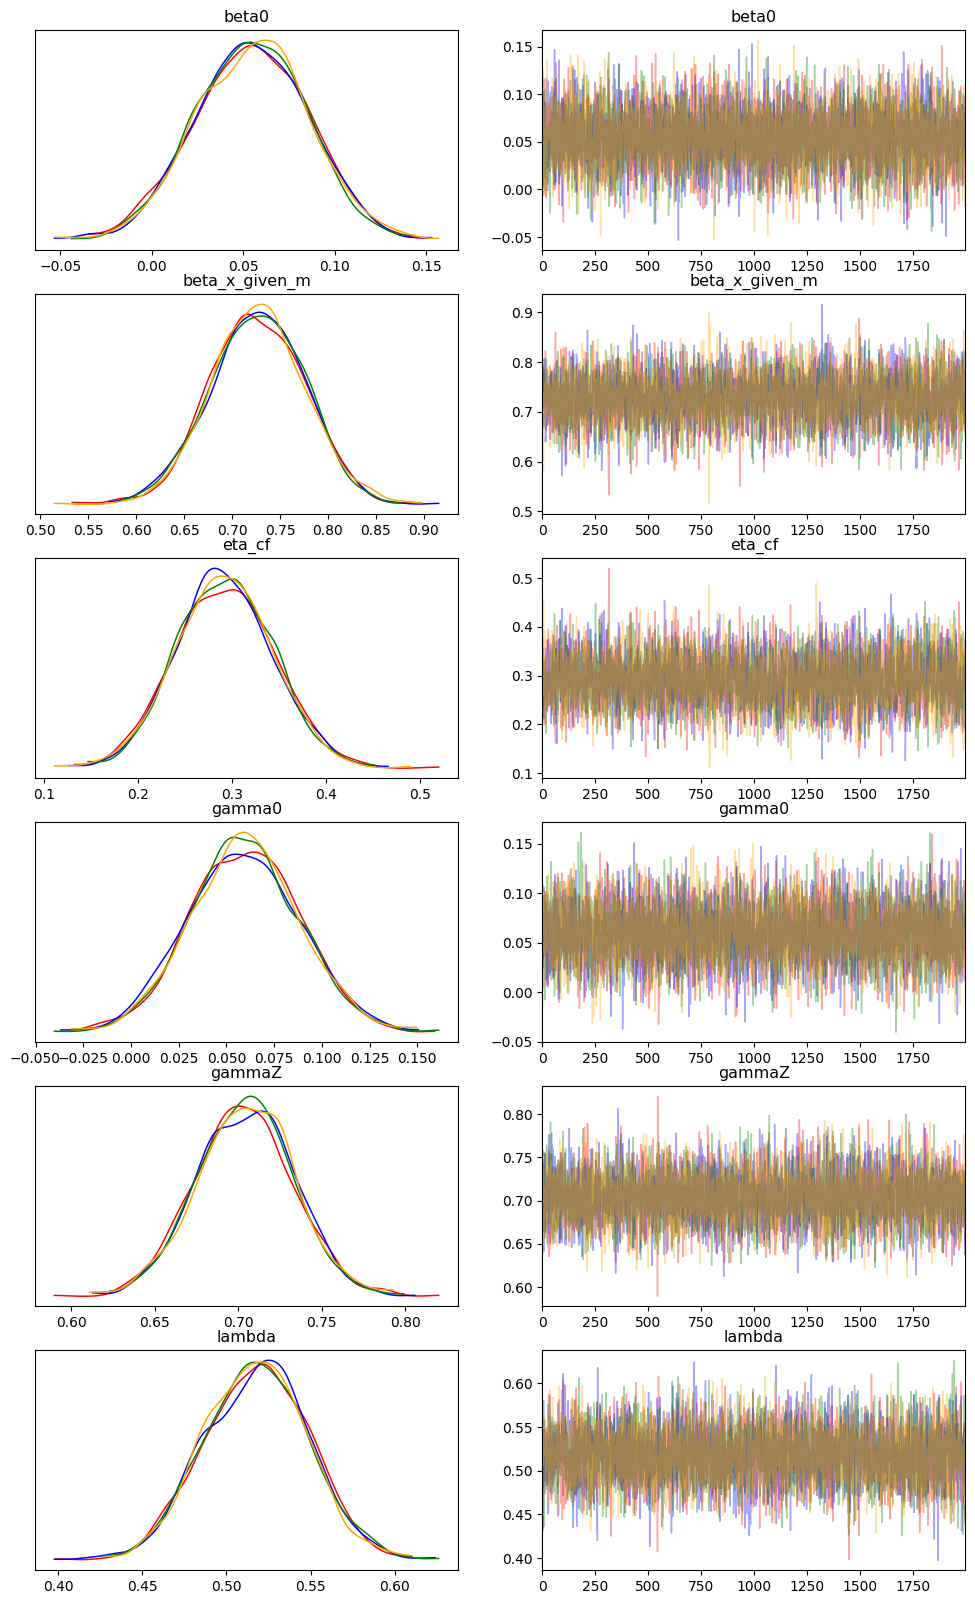

In [25]:
# Plot divergences
az.plot_trace(
        lambda_idata,
        var_names=["~sample_stats"],
        divergences="top",
        compact=True,
        chain_prop={'color': ['red', 'blue', 'green', 'orange']},
        figsize=(12, 20)
    )

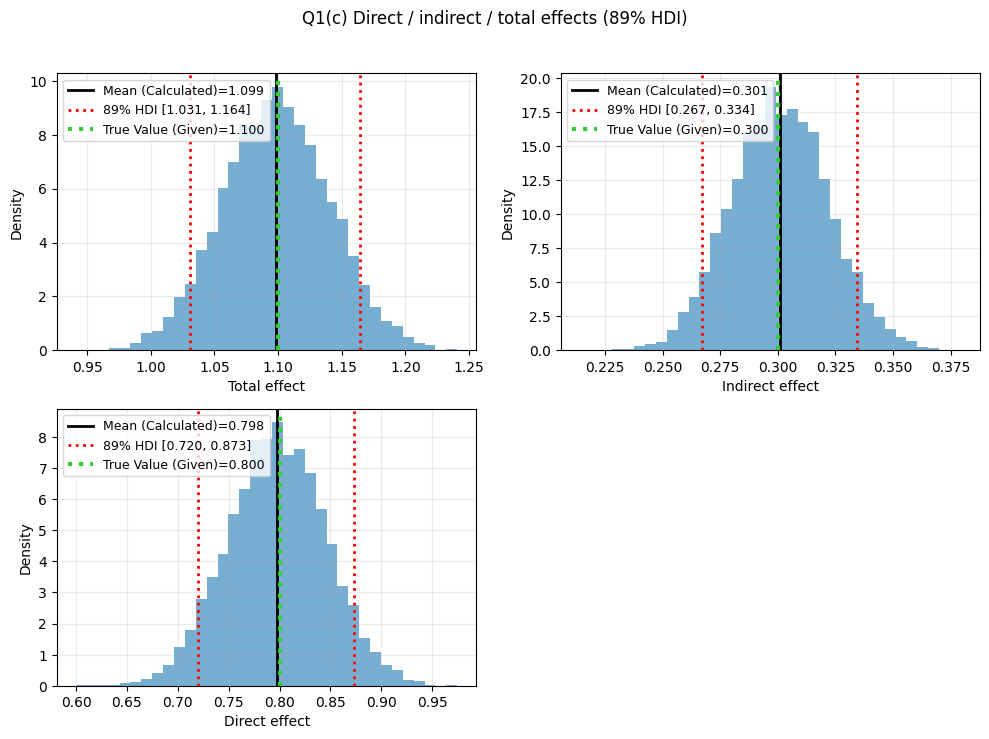

In [26]:
# Q1(b) identified beta_total using the instrument Z.
post_beta_total = np.asarray(iv_samp["beta_total"])

# The indirect path is X -> M -> Y, so beta_indirect = delta * lambda.
post_delta = np.asarray(med_samp["delta"])
post_lambda = np.asarray(lambda_samp["lambda"])

post_beta_indirect = post_delta * post_lambda
post_beta_direct = post_beta_total - post_beta_indirect
post_beta_total_from_parts = post_beta_direct + post_beta_indirect

plot_posteriors(
    {
        "beta_total": post_beta_total_from_parts,
        "beta_indirect": post_beta_indirect,
        "beta_direct": post_beta_direct,
    },
    title="Q1(c) Direct / indirect / total effects (89% HDI)",
    ref_values={"beta_direct": 0.8, "beta_indirect": 0.3, "beta_total": 1.1},
    xlabels={
        "beta_total": "Total effect",
        "beta_indirect": "Indirect effect",
        "beta_direct": "Direct effect",
    },
)

### Q1(d) Individual counterfactual vs new-farmer predictive

In [27]:
# pick one treated farmer
idx_i = int(q1["X"].idxmax())
row_i = q1.iloc[idx_i]

In [28]:
x_i = float(row_i["X"])
m_i = float(row_i["M"])
y_i = float(row_i["Y"])
z_i = float(row_i["Z"])
w_i = float(row_i["W"])

In [29]:
print(f"Selected treated farmer index: {idx_i}")
print(f"Observed (Z, W, X, M, Y)=({z_i:.3f}, {w_i:.3f}, {x_i:.3f}, {m_i:.3f}, {y_i:.3f})")

Selected treated farmer index: 212
Observed (Z, W, X, M, Y)=(1.207, 1.243, 3.695, 1.166, 1.114)


In [30]:
# Posterior draws
beta0_draw = np.asarray(lambda_samp["beta0"])
beta_direct_draw = post_beta_direct
lambda_draw = post_lambda
delta0_draw = np.asarray(med_samp["delta0"])
delta_draw = post_delta

# If we want to use the same variance for all draws
sigma_m_draw = np.full(len(lambda_samp["beta0"]), 0.5)
sigma_y_draw = np.full(len(lambda_samp["beta0"]), 0.5)

In [31]:
# Abduction: infer farmer-specific residuals from observed world
eps_m_i = m_i - (delta0_draw + delta_draw * x_i) # delta0_draw and delta_draw are shape (n_draws,), x_i = 3.695
eps_y_i = y_i - (beta0_draw + beta_direct_draw * x_i + lambda_draw * m_i)

In [32]:
# Action: set X_cf=0, keep person-specific residual shocks frozen
x_cf = 0.0

In [33]:
# Prediction: We calcualte crop yield had the farmer used no fertilizer 
m_cf = delta0_draw + delta_draw * x_cf + eps_m_i
y_cf = beta0_draw + beta_direct_draw * x_cf + lambda_draw * m_cf + eps_y_i

In [34]:
# New Farmer
x_new = 0.0

In [35]:
# Posterior predictive for a new farmer with X=0
rng = np.random.default_rng(99)

# Sample new random errors based on the FITTED model variances, which absorb U
eps_m_new = rng.normal(0, sigma_m_draw)
eps_y_new = rng.normal(0, sigma_y_draw)

m_new = delta0_draw + delta_draw * x_new + eps_m_new
y_new = beta0_draw + beta_direct_draw * x_new + lambda_draw * m_new + eps_y_new

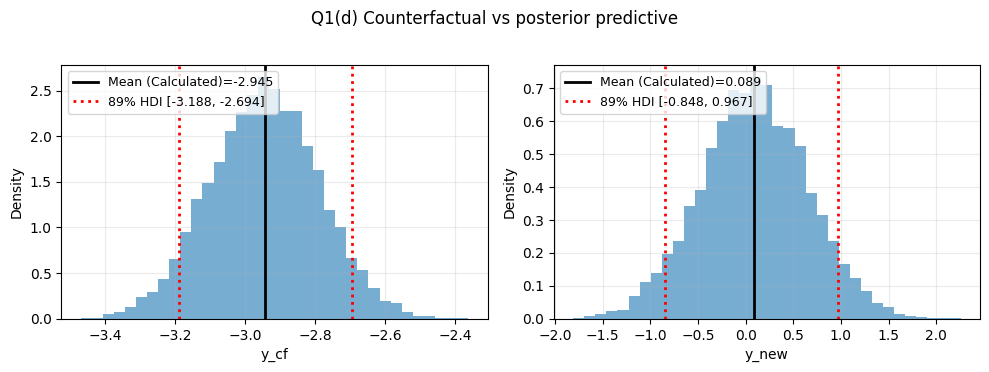

In [36]:
# Display the results
plot_posteriors(
    {
        "y_cf": y_cf,
        "y_new": y_new,
    },
    title="Q1(d) Counterfactual vs posterior predictive",
)


## Q2. Teaching Pedagogy and Student Evaluations

## EDA

In [37]:
q2.head()

,department,year,treatment,rating
0,6,3,0,5
1,3,3,0,3
2,10,2,0,4
3,7,2,0,2
4,4,4,0,5


In [38]:
q2.describe()

,department,year,treatment,rating
count,400.000000,400.000000,400.00000,400.000000
mean,5.452500,2.665000,0.49750,3.535000
std,3.573467,1.051446,0.50062,1.379686
min,0.000000,1.000000,0.00000,1.000000
25%,2.000000,2.000000,0.00000,3.000000
50%,6.000000,3.000000,0.00000,4.000000
75%,8.000000,4.000000,1.00000,5.000000
max,11.000000,4.000000,1.00000,5.000000


In [39]:
q2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   department  400 non-null    int64
 1   year        400 non-null    int64
 2   treatment   400 non-null    int64
 3   rating      400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [40]:
# Num unique values in each column
q2.nunique()

department    12
year           4
treatment      2
rating         5
dtype: int64

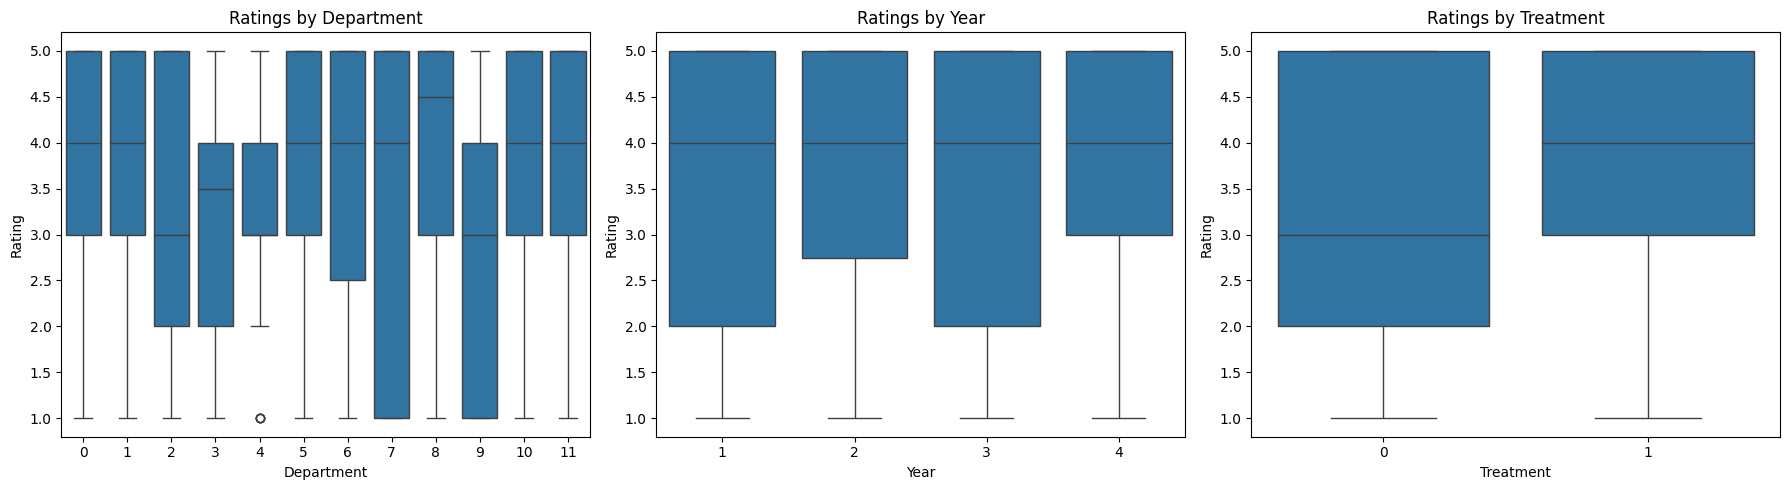

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Ratings by department
sns.boxplot(x="department", y="rating", data=q2, ax=axs[0])
axs[0].set_title("Ratings by Department")
axs[0].set_xlabel("Department")
axs[0].set_ylabel("Rating")

# Ratings by year
sns.boxplot(x="year", y="rating", data=q2, ax=axs[1])
axs[1].set_title("Ratings by Year")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Rating")

# Ratings by treatment
sns.boxplot(x="treatment", y="rating", data=q2, ax=axs[2])
axs[2].set_title("Ratings by Treatment")
axs[2].set_xlabel("Treatment")
axs[2].set_ylabel("Rating")

plt.tight_layout()
plt.show()

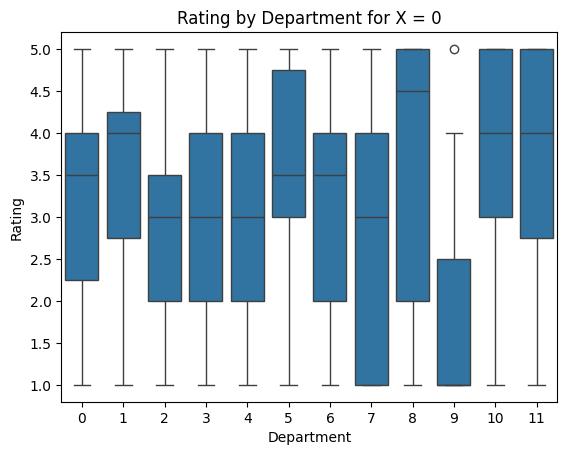

In [42]:
# Rating by department for X = 0
q2_0 = q2[q2["treatment"] == 0]
sns.boxplot(x="department", y="rating", data=q2_0)
plt.title("Rating by Department for X = 0")
plt.xlabel("Department")
plt.ylabel("Rating")
plt.show()


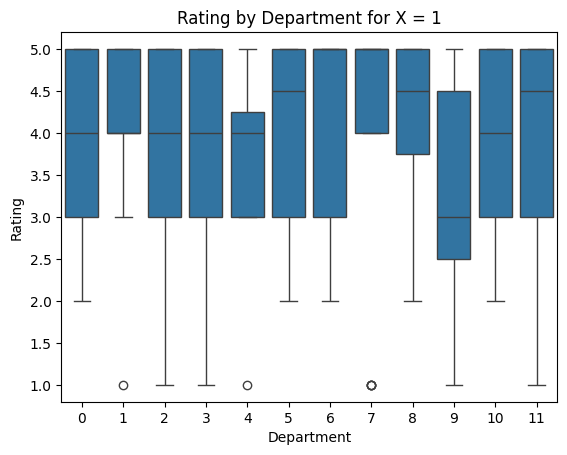

In [43]:
# Rating by department for X = 1
q2_1 = q2[q2["treatment"] == 1]
sns.boxplot(x="department", y="rating", data=q2_1)
plt.title("Rating by Department for X = 1")
plt.xlabel("Department")
plt.ylabel("Rating")
plt.show()

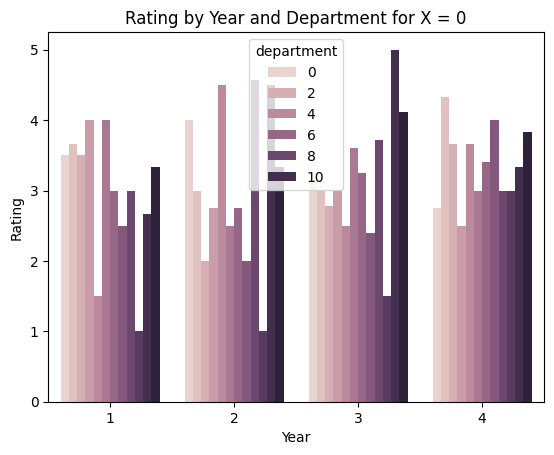

In [44]:
# Rating by year and department for X = 0
q2_0_year_dept = q2_0.groupby(["year", "department"]).agg({"rating": "mean"}).reset_index()
sns.barplot(x="year", y="rating", data=q2_0_year_dept, hue="department")
plt.title("Rating by Year and Department for X = 0")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

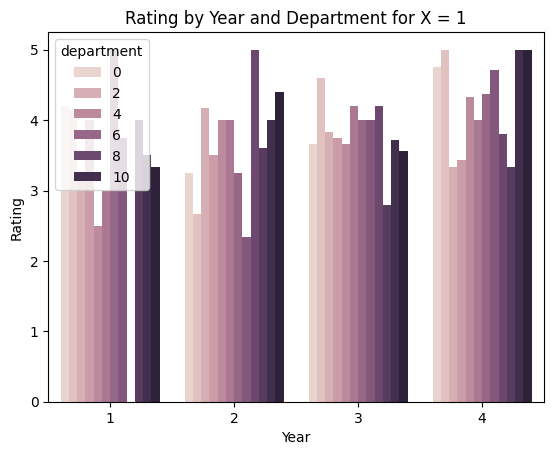

In [45]:
# Rating by year and department for X = 1
q2_1_year_dept = q2_1.groupby(["year", "department"]).agg({"rating": "mean"}).reset_index()
sns.barplot(x="year", y="rating", data=q2_1_year_dept, hue="department")
plt.title("Rating by Year and Department for X = 1")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

In [46]:
# Number of students in each department
q2_dept_counts = q2.groupby("department").size().reset_index(name="count")
print(q2_dept_counts)
# Number of students in each year
q2_year_counts = q2.groupby("year").size().reset_index(name="count")
print(q2_year_counts)



    department  count
0            0     42
1            1     28
2            2     39
3            3     32
4            4     29
5            5     28
6            6     35
7            7     37
8            8     32
9            9     26
10          10     28
11          11     44
   year  count
0     1     74
1     2     88
2     3    136
3     4    102


In [47]:
# Number of x = 1 by department for year 1
q2_1_year_dept_1 = q2_1[q2_1["year"] == 1].groupby(["department"]).size().reset_index(name="count")
print(q2_1_year_dept_1)



    department  count
0            0      5
1            1      7
2            2      5
3            3      2
4            4      2
5            5      3
6            6      1
7            7      4
8            9      2
9           10      4
10          11      3


In [48]:
department = jnp.asarray(q2["department"].values.astype(int))
year_idx = jnp.asarray(q2["year"].values.astype(int) - 1)  
treatment = jnp.asarray(q2["treatment"].values.astype(int))
rating = jnp.asarray(q2["rating"].values.astype(int) - 1)  
n_dept = int(q2["department"].nunique()) 

## Q2(a)

In [49]:
def q2_ordered_model(department, year_idx, treatment, rating=None, n_dept=12):

    # CUTPOINTS for 5 response categories (4 cutpoints)
    c = numpyro.sample('c', dist.TransformedDistribution(
        dist.Normal(0, 1.5).expand([4]),  #Standard normal
        dist.transforms.OrderedTransform()
    ))
    
    # PRIORS
    # Effect of treatment on rating
    # We can start with the assumption that there is no effect of treatment on rating (0) but allow for some variation (1)
    beta_X = numpyro.sample('beta_X', dist.Normal(0, 0.8))
    
    # Effect of year on rating
    # We can start with the assumption that there is no effect of year on rating (0) but allow for large variation/surprises (1)
    beta_Z = numpyro.sample('beta_Z', dist.Cauchy(0, 10)) # Learn from the data instead of using informative priors (large enough sample size allows for this)

    # Given Dirichlet(2) enforces that year increments are strictly non-negative
    delta = numpyro.sample('delta', dist.Dirichlet(jnp.full(3, 2.0))) #Given
    
    # delta_tilde = cumsum(delta). Freshman (year_idx=0) gets a 0.0 baseline.
    delta_padded = jnp.cumsum(jnp.concatenate([jnp.zeros(1), delta]))
    delta_tilde_Z_i = delta_padded[year_idx]
    
    # Department-level variation (Non-centered parameterization for better sampling
    sigma_dept = numpyro.sample('sigma_dept', dist.Exponential(0.1))
    with numpyro.plate('dept_plate', n_dept):
        z_dept_raw = numpyro.sample('z_dept', dist.Normal(0, 1)) # Given
    alpha_dept = numpyro.deterministic('alpha_dept', sigma_dept * z_dept_raw)

    # Explicitly track and save the scaled cumulative effects
    numpyro.deterministic('cumulative_year_effects', beta_Z * delta_padded)
    
    # LINEAR PREDICTOR
    # GIVEN LINEARITY MODEL
    phi = beta_X * treatment + beta_Z * delta_tilde_Z_i + alpha_dept[department]
    
    # LIKELIHOOD
    with numpyro.plate('data', len(department)):
        numpyro.sample('obs', dist.OrderedLogistic(phi, c), obs=rating)

In [50]:
k_q2 = random.PRNGKey(2)
q2_mcmc, q2_idata, q2_samp = run_mcmc(
    q2_ordered_model, k_q2,
    department=department, year_idx=year_idx,
    treatment=treatment, rating=rating, n_dept=n_dept,
    num_warmup=2000, num_samples=4000, num_chains=4,
    nuts_kwargs={"target_accept_prob": 0.95},
)

In [51]:
az.summary(q2_idata, var_names=["beta_X", "beta_Z", "sigma_dept", "delta", "c", "cumulative_year_effects"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_X,0.810,0.181,0.514,1.096,0.001,0.001,18291.0,12744.0,1.0
beta_Z,0.441,0.256,0.022,0.839,0.002,0.002,15924.0,11502.0,1.0
sigma_dept,0.381,0.185,0.088,0.658,0.003,0.002,3869.0,4145.0,1.0
delta[0],0.342,0.170,0.071,0.604,0.001,0.001,21270.0,9276.0,1.0
delta[1],0.292,0.164,0.038,0.533,0.001,0.001,21857.0,11473.0,1.0
delta[2],0.366,0.172,0.070,0.615,0.001,0.001,20553.0,11418.0,1.0
c[0],-1.427,0.251,-1.830,-1.035,0.002,0.002,10614.0,10378.0,1.0
c[1],-0.488,0.237,-0.878,-0.127,0.002,0.002,10912.0,10032.0,1.0
c[2],0.434,0.237,0.052,0.801,0.002,0.002,10608.0,9947.0,1.0
c[3],1.362,0.245,0.983,1.759,0.002,0.002,10916.0,10361.0,1.0


In [52]:
# Count divergences
print(f"Divergences: {count_divergences(q2_idata)}")


Divergences: 0


array([[<Axes: title={'center': 'alpha_dept'}>,
        <Axes: title={'center': 'alpha_dept'}>],
       [<Axes: title={'center': 'beta_X'}>,
        <Axes: title={'center': 'beta_X'}>],
       [<Axes: title={'center': 'beta_Z'}>,
        <Axes: title={'center': 'beta_Z'}>],
       [<Axes: title={'center': 'c'}>, <Axes: title={'center': 'c'}>],
       [<Axes: title={'center': 'cumulative_year_effects'}>,
        <Axes: title={'center': 'cumulative_year_effects'}>],
       [<Axes: title={'center': 'delta'}>,
        <Axes: title={'center': 'delta'}>],
       [<Axes: title={'center': 'sigma_dept'}>,
        <Axes: title={'center': 'sigma_dept'}>],
       [<Axes: title={'center': 'z_dept'}>,
        <Axes: title={'center': 'z_dept'}>]], dtype=object)

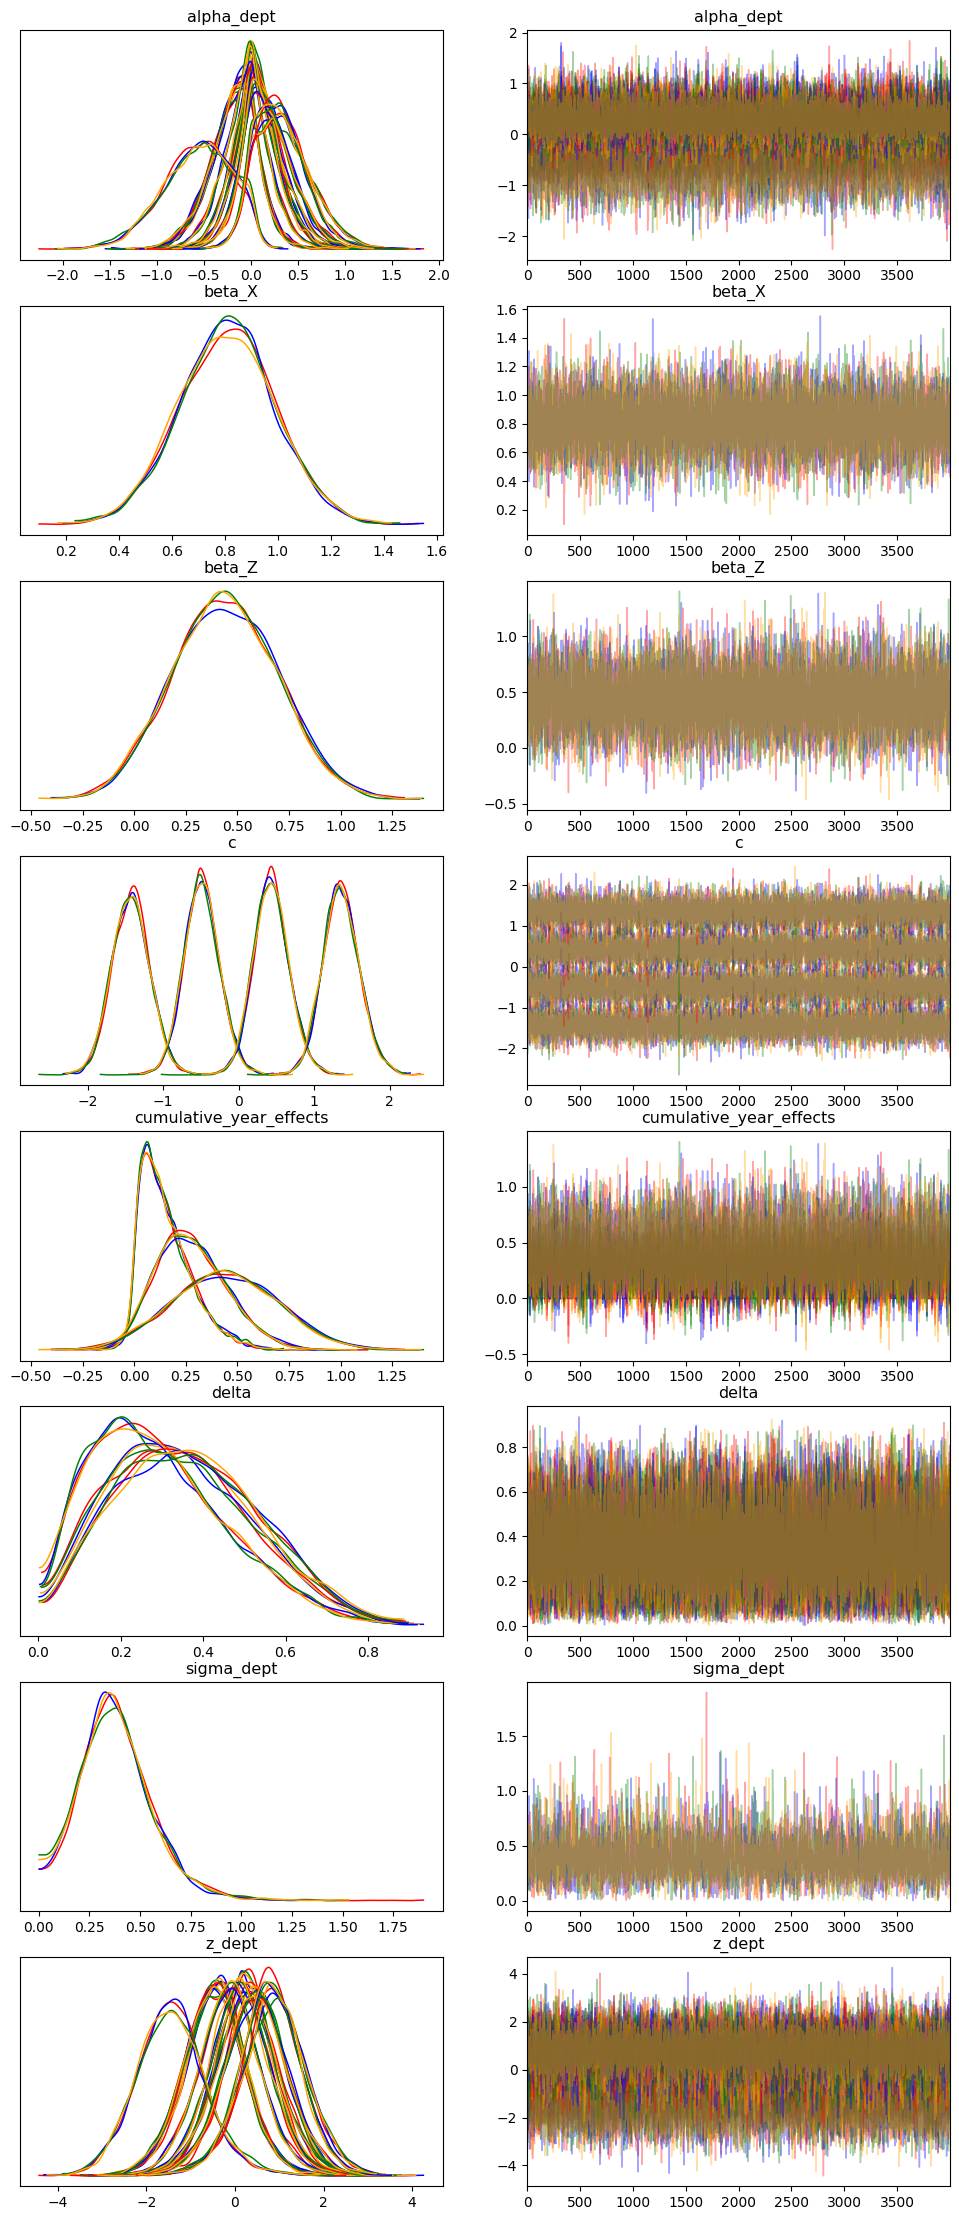

In [53]:
# Plot divergences
az.plot_trace(
        q2_idata,
        var_names=["~sample_stats"],
        divergences="top", 
        compact=True,
        chain_prop={'color': ['red', 'blue', 'green', 'orange']},
        figsize=(12, 28)
    )


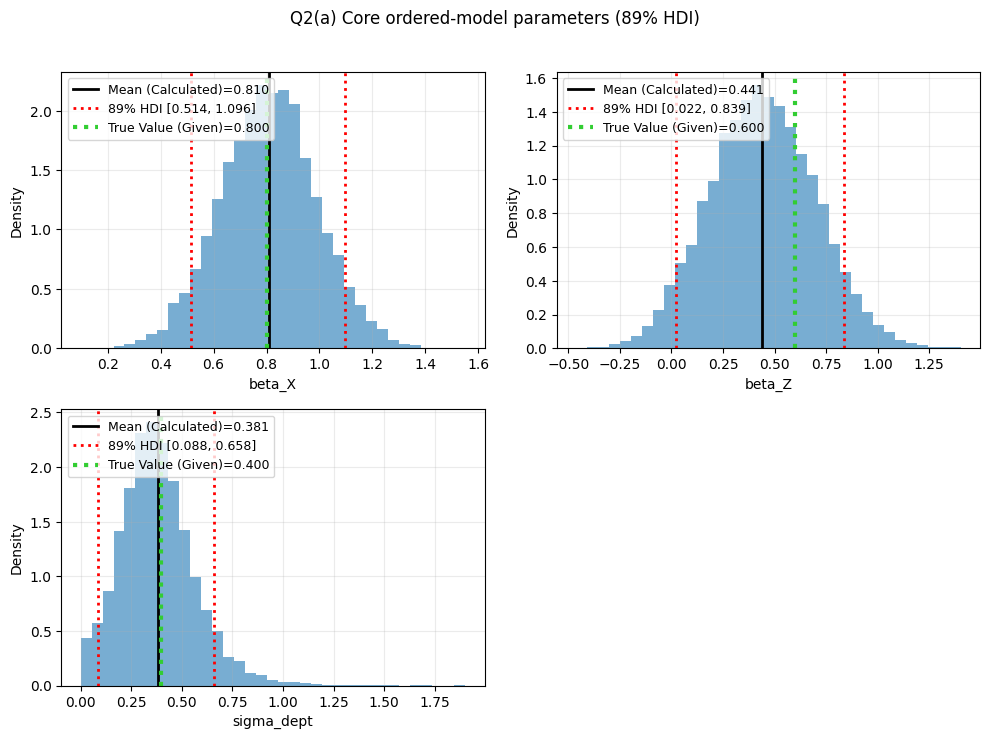

In [54]:
plot_posteriors(
    {
        "beta_X": q2_samp["beta_X"],
        "beta_Z": q2_samp["beta_Z"],
        "sigma_dept": q2_samp["sigma_dept"],
    },
    title="Q2(a) Core ordered-model parameters (89% HDI)",
    ref_values={"beta_X": 0.8, "beta_Z": 0.6, "sigma_dept": 0.4},
)

## Q2 (b) ATE on the Probability Scale

In [58]:
def compute_q2b_exceedance_ate(samples, year_idx, department, hdi_prob=HDI_PROB):
    """Compute ATE on exceedance probabilities Pr(Y >= k), k=1..5."""
    year_idx_np = np.asarray(year_idx, dtype=int)
    department_np = np.asarray(department, dtype=int)

    beta_x = np.asarray(samples["beta_X"])  # (draws,)
    beta_z = np.asarray(samples["beta_Z"])  # (draws,)
    cutpoints = np.asarray(samples["c"])    # (draws, 4)
    delta = np.asarray(samples["delta"])    # (draws, 3)

    if "alpha_dept" in samples:
        alpha_dept = np.asarray(samples["alpha_dept"])  # (draws, n_dept)
    else:
        sigma_dept = np.asarray(samples["sigma_dept"])  # (draws,)
        z_dept = np.asarray(samples["z_dept"])          # (draws, n_dept)
        alpha_dept = sigma_dept[:, None] * z_dept

    delta_padded = np.concatenate(
        [np.zeros((delta.shape[0], 1)), np.cumsum(delta, axis=1)],
        axis=1,
    )

    year_effect = beta_z[:, None] * delta_padded[:, year_idx_np]
    dept_effect = alpha_dept[:, department_np]

    phi_control = year_effect + dept_effect
    phi_treated = phi_control + beta_x[:, None]

    def exceedance_prob(phi, cuts, k):
        if k == 1:
            return np.ones_like(phi)
        cut = cuts[:, k - 2][:, None]
        cdf = 1.0 / (1.0 + np.exp(-(cut - phi)))
        return 1.0 - cdf

    rows = []
    draw_level = {}

    for k in range(1, 6):
        p_treated = exceedance_prob(phi_treated, cutpoints, k)
        p_control = exceedance_prob(phi_control, cutpoints, k)

        treated_draw = p_treated.mean(axis=1)
        control_draw = p_control.mean(axis=1)
        ate_draw = treated_draw - control_draw

        hdi_low, hdi_high = az.hdi(ate_draw, hdi_prob=hdi_prob)

        rows.append(
            {
                "threshold_k": k,
                "E[Pr(Y>=k)|X=1]": treated_draw.mean(),
                "E[Pr(Y>=k)|X=0]": control_draw.mean(),
                "ATE": ate_draw.mean(),
                "89%_HDI_low": hdi_low,
                "89%_HDI_high": hdi_high,
            }
        )

        draw_level[k] = {
            "treated": treated_draw,
            "control": control_draw,
            "ate": ate_draw,
        }

    return pd.DataFrame(rows), draw_level

In [59]:
q2b_table, q2b_draws = compute_q2b_exceedance_ate(
    q2_samp,
    year_idx=year_idx,
    department=department,
    hdi_prob=HDI_PROB,
)
q2b_table

,threshold_k,E[Pr(Y>=k)|X=1],E[Pr(Y>=k)|X=0],ATE,89%_HDI_low,89%_HDI_high
0,1,1.000000,1.000000,0.000000,0.000000,0.000000
1,2,0.918698,0.836625,0.082073,0.048914,0.112630
2,3,0.818777,0.673512,0.145265,0.090863,0.195124
3,4,0.649281,0.459167,0.190114,0.125736,0.258668
4,5,0.430920,0.257232,0.173688,0.115327,0.236974


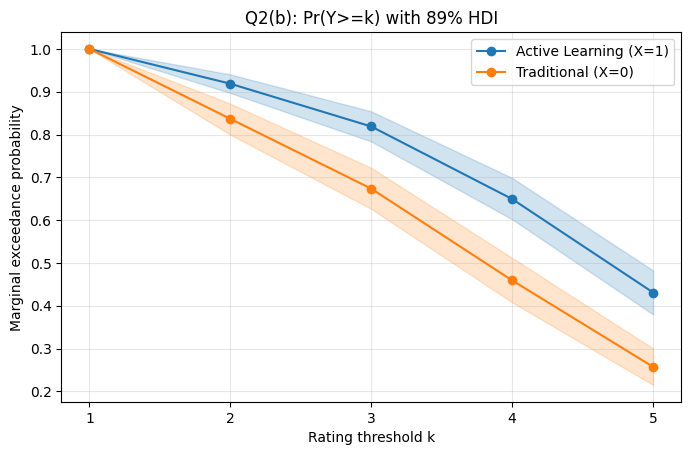

In [61]:
k_vals = q2b_table["threshold_k"].values

treated_mean = q2b_table["E[Pr(Y>=k)|X=1]"].values
control_mean = q2b_table["E[Pr(Y>=k)|X=0]"].values

treated_hdi = np.array([az.hdi(q2b_draws[int(k)]["treated"], hdi_prob=HDI_PROB) for k in k_vals])
control_hdi = np.array([az.hdi(q2b_draws[int(k)]["control"], hdi_prob=HDI_PROB) for k in k_vals])

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(k_vals, treated_mean, marker="o", label="Active Learning (X=1)", color="tab:blue")
ax.fill_between(k_vals, treated_hdi[:, 0], treated_hdi[:, 1], color="tab:blue", alpha=0.2)

ax.plot(k_vals, control_mean, marker="o", label="Traditional (X=0)", color="tab:orange")
ax.fill_between(k_vals, control_hdi[:, 0], control_hdi[:, 1], color="tab:orange", alpha=0.2)

ax.set_xticks(k_vals)
ax.set_xlabel("Rating threshold k")
ax.set_ylabel("Marginal exceedance probability")
ax.set_title(f"Q2(b): Pr(Y>=k) with {int(HDI_PROB * 100)}% HDI")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Q2 (c) Year-specific and post-stratified ATE

In [73]:
def compute_q2c_year_specific_ate(samples, year_idx, department, hdi_prob=HDI_PROB, year_weights=None):
    """Compute year-specific and post-stratified ATEs on exceedance probabilities."""
    year_idx_np = np.asarray(year_idx, dtype=int)
    department_np = np.asarray(department, dtype=int)

    beta_x = np.asarray(samples["beta_X"])   # (draws,)
    beta_z = np.asarray(samples["beta_Z"])   # (draws,)
    cutpoints = np.asarray(samples["c"])     # (draws, 4)
    delta = np.asarray(samples["delta"])     # (draws, 3)

    if "alpha_dept" in samples:
        alpha_dept = np.asarray(samples["alpha_dept"])  # (draws, n_dept)
    else:
        sigma_dept = np.asarray(samples["sigma_dept"])  # (draws,)
        z_dept = np.asarray(samples["z_dept"])          # (draws, n_dept)
        alpha_dept = sigma_dept[:, None] * z_dept

    delta_padded = np.concatenate(
        [np.zeros((delta.shape[0], 1)), np.cumsum(delta, axis=1)],
        axis=1,
    )  # (draws, 4)

    if year_weights is None:
        year_weights = np.array([0.15, 0.25, 0.35, 0.25], dtype=float)
    year_weights = np.asarray(year_weights, dtype=float)
    year_weights = year_weights / year_weights.sum()

    year_names = ["Freshman", "Sophomore", "Junior", "Senior"]

    def exceedance_prob(phi, cuts, k):
        if k == 1:
            return np.ones_like(phi)
        cut = cuts[:, k - 2][:, None]
        cdf = 1.0 / (1.0 + np.exp(-(cut - phi)))
        return 1.0 - cdf

    dept_effect_obs = alpha_dept[:, department_np]  # (draws, N)

    # Overall ATE from observed sample distribution (for comparison with part b)
    year_effect_obs = beta_z[:, None] * delta_padded[:, year_idx_np]
    phi_control_obs = year_effect_obs + dept_effect_obs
    phi_treated_obs = phi_control_obs + beta_x[:, None]

    overall_ate_draws = {}
    for k in range(1, 6):
        p_t = exceedance_prob(phi_treated_obs, cutpoints, k)
        p_c = exceedance_prob(phi_control_obs, cutpoints, k)
        overall_ate_draws[k] = p_t.mean(axis=1) - p_c.mean(axis=1)

    # Year-specific ATEs using each year's observed department composition
    year_rows = []
    year_ate_draws = {y: {} for y in range(4)}

    for y in range(4):
        mask_y = year_idx_np == y
        if not np.any(mask_y):
            raise ValueError(f"No observations found for year index {y}.")

        dept_effect_y = alpha_dept[:, department_np[mask_y]]
        year_effect = (beta_z * delta_padded[:, y])[:, None]
        phi_control_y = year_effect + dept_effect_y
        phi_treated_y = phi_control_y + beta_x[:, None]

        for k in range(1, 6):
            p_t = exceedance_prob(phi_treated_y, cutpoints, k)
            p_c = exceedance_prob(phi_control_y, cutpoints, k)

            treated_draw = p_t.mean(axis=1)
            control_draw = p_c.mean(axis=1)
            ate_draw = treated_draw - control_draw

            year_ate_draws[y][k] = ate_draw
            hdi_low, hdi_high = az.hdi(ate_draw, hdi_prob=hdi_prob)

            year_rows.append(
                {
                    "year_idx": y + 1,
                    "year": year_names[y],
                    "threshold_k": k,
                    "E[Pr(Y>=k)|X=1]": treated_draw.mean(),
                    "E[Pr(Y>=k)|X=0]": control_draw.mean(),
                    "ATE": ate_draw.mean(),
                    "89%_HDI_low": hdi_low,
                    "89%_HDI_high": hdi_high,
                }
            )

    year_table = pd.DataFrame(year_rows)

    # Post-stratified ATE by threshold using provided population year weights
    post_rows = []
    post_ate_draws = {}

    for k in range(1, 6):
        post_draw = sum(year_weights[y] * year_ate_draws[y][k] for y in range(4))
        post_ate_draws[k] = post_draw

        post_low, post_high = az.hdi(post_draw, hdi_prob=hdi_prob)
        overall_draw = overall_ate_draws[k]

        post_rows.append(
            {
                "threshold_k": k,
                "post_strat_ATE": post_draw.mean(),
                "89%_HDI_low": post_low,
                "89%_HDI_high": post_high,
                "overall_ATE_part_b": overall_draw.mean(),
                "post_minus_overall": post_draw.mean() - overall_draw.mean(),
            }
        )

    post_table = pd.DataFrame(post_rows)

    draw_dict = {
        "year_ate_draws": year_ate_draws,
        "overall_ate_draws": overall_ate_draws,
        "post_ate_draws": post_ate_draws,
        "year_weights": year_weights,
    }

    return year_table, post_table, draw_dict

In [74]:
q2c_year_table, q2c_post_table, q2c_draws = compute_q2c_year_specific_ate(
    q2_samp,
    year_idx=year_idx,
    department=department,
    hdi_prob=HDI_PROB,
    year_weights=[0.15, 0.25, 0.35, 0.25],
)

display(q2c_year_table)
display(q2c_post_table)

,year_idx,year,threshold_k,E[Pr(Y>=k)|X=1],E[Pr(Y>=k)|X=0],ATE,89%_HDI_low,89%_HDI_high
0,1,Freshman,1,1.000000,1.000000,0.000000,0.000000,0.000000
1,1,Freshman,2,0.899919,0.802795,0.097124,0.056837,0.137769
2,1,Freshman,3,0.782244,0.620693,0.161550,0.101227,0.220115
3,1,Freshman,4,0.594878,0.401358,0.193520,0.127948,0.263052
4,1,Freshman,5,0.374000,0.213732,0.160268,0.103886,0.220466
5,2,Sophomore,1,1.000000,1.000000,0.000000,0.000000,0.000000
6,2,Sophomore,2,0.914079,0.828024,0.086054,0.052756,0.120666
7,2,Sophomore,3,0.809404,0.659187,0.150218,0.095587,0.203961
8,2,Sophomore,4,0.634382,0.442186,0.192197,0.126727,0.260439
9,2,Sophomore,5,0.414037,0.243485,0.170553,0.110267,0.230463


,threshold_k,post_strat_ATE,89%_HDI_low,89%_HDI_high,overall_ATE_part_b,post_minus_overall
0,1,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,0.081695,0.048822,0.112278,0.082073,-0.000378
2,3,0.144884,0.092823,0.196845,0.145265,-0.000381
3,4,0.190080,0.124788,0.257722,0.190114,-0.000034
4,5,0.174044,0.115716,0.237669,0.173688,0.000356


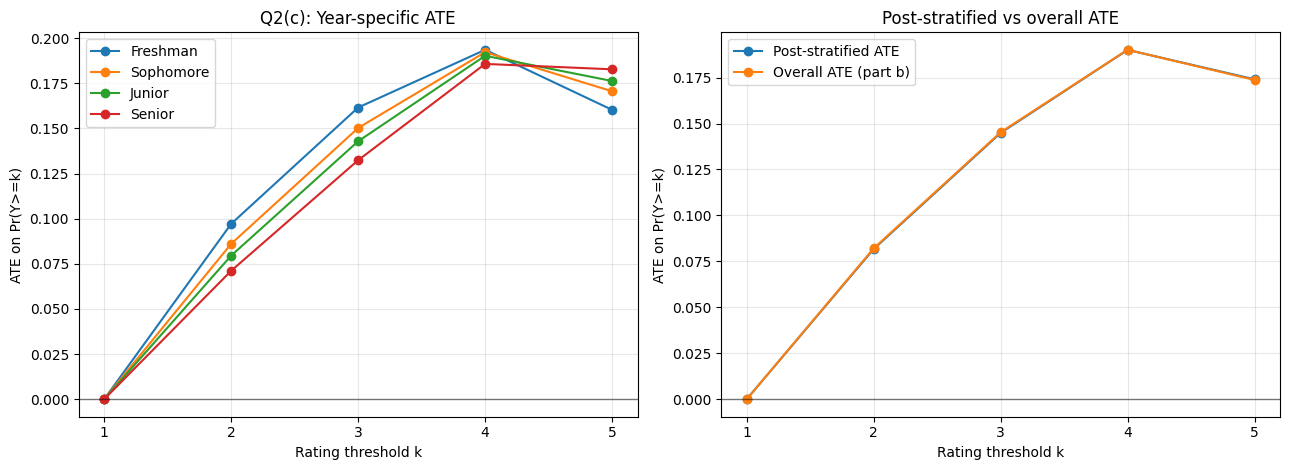

In [75]:
year_order = ["Freshman", "Sophomore", "Junior", "Senior"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: year-specific ATE curves across thresholds
for year_name in year_order:
    sub = q2c_year_table[q2c_year_table["year"] == year_name].sort_values("threshold_k")
    axes[0].plot(sub["threshold_k"], sub["ATE"], marker="o", label=year_name)

axes[0].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[0].set_xlabel("Rating threshold k")
axes[0].set_ylabel("ATE on Pr(Y>=k)")
axes[0].set_title("Q2(c): Year-specific ATE")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(alpha=0.3)
axes[0].legend()

# Right: post-stratified vs overall ATE (from part b distribution)
k_vals = q2c_post_table["threshold_k"].values
axes[1].plot(k_vals, q2c_post_table["post_strat_ATE"], marker="o", label="Post-stratified ATE")
axes[1].plot(k_vals, q2c_post_table["overall_ATE_part_b"], marker="o", label="Overall ATE (part b)")
axes[1].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[1].set_xlabel("Rating threshold k")
axes[1].set_ylabel("ATE on Pr(Y>=k)")
axes[1].set_title("Post-stratified vs overall ATE")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

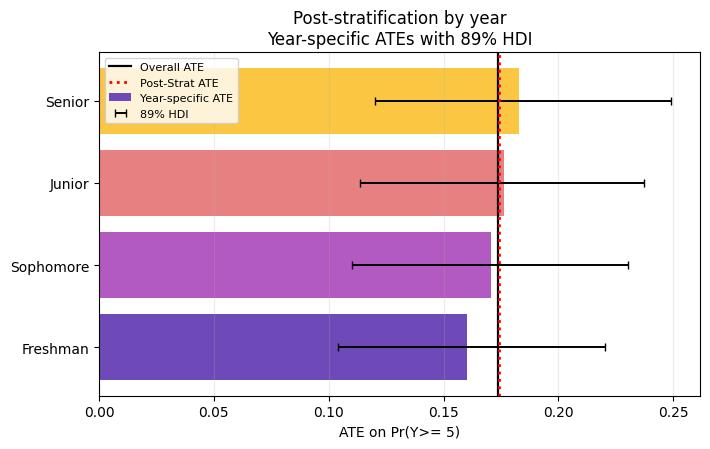

In [76]:
# Post-stratification chart (single threshold)
k_plot = 5  # Change to 2, 3, 4, or 5 if you want a different exceedance threshold

year_order = ["Freshman", "Sophomore", "Junior", "Senior"]
sub = (
    q2c_year_table[q2c_year_table["threshold_k"] == k_plot]
    .set_index("year")
    .loc[year_order]
    .reset_index()
)

row = q2c_post_table[q2c_post_table["threshold_k"] == k_plot].iloc[0]
overall_ate = row["overall_ATE_part_b"]
post_ate = row["post_strat_ATE"]

y_pos = np.arange(len(year_order))
colors = ["#5E35B1", "#AB47BC", "#E57373", "#FBC02D"]

fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.barh(
    y_pos,
    sub["ATE"].values,
    color=colors,
    alpha=0.9,
    label="Year-specific ATE",
)

xerr = np.vstack([
    sub["ATE"].values - sub["89%_HDI_low"].values,
    sub["89%_HDI_high"].values - sub["ATE"].values,
])
ax.errorbar(
    sub["ATE"].values,
    y_pos,
    xerr=xerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.4,
    capsize=3,
    label=f"{int(HDI_PROB * 100)}% HDI",
)

ax.axvline(overall_ate, color="black", linestyle="-", linewidth=1.6, label="Overall ATE")
ax.axvline(post_ate, color="red", linestyle=":", linewidth=2.0, label="Post-Strat ATE")

ax.set_yticks(y_pos)
ax.set_yticklabels(year_order)
ax.set_xlabel(f"ATE on Pr(Y>= {k_plot})")
ax.set_title(
    f"Post-stratification by year\nYear-specific ATEs with {int(HDI_PROB * 100)}% HDI"
)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## Q2(d) Naive Model


In [97]:
def q2_linear_model(department, year_idx, treatment, rating=None, n_dept=12):
    """
    Naive model: treat ordinal rating as continuous Gaussian outcome.
    Identical predictor structure to ordinal model for fair comparison.
    """
    intercept = numpyro.sample("intercept", dist.Normal(0.0, 1.0))
    beta_X    = numpyro.sample("beta_X",    dist.Normal(0, 1))
    beta_Z    = numpyro.sample("beta_Z",    dist.Normal(0, 1))
    delta     = numpyro.sample("delta",     dist.Dirichlet(jnp.full(3, 2.0)))
    sigma     = numpyro.sample("sigma",     dist.Exponential(1.0))

    delta_padded   = jnp.cumsum(jnp.concatenate([jnp.zeros(1), delta]))
    delta_tilde_Zi = delta_padded[year_idx]

    sigma_dept = numpyro.sample("sigma_dept", dist.Exponential(0.1))
    with numpyro.plate("dept_plate", n_dept):
        z_dept = numpyro.sample("z_dept", dist.Normal(0, 1))
    alpha_dept = numpyro.deterministic("alpha_dept", sigma_dept * z_dept)

    mu = (
        intercept
        + beta_X * treatment
        + beta_Z * delta_tilde_Zi
        + alpha_dept[department]
    )

    with numpyro.plate("data", len(department)):
        numpyro.sample(
            "obs",
            dist.Normal(mu, sigma),
            obs=rating.astype(float) if rating is not None else None,
        )

In [98]:
# Rating stays on 1-5 scale for the linear model
rating_cont = jnp.asarray(q2["rating"].values.astype(float))

k_q2d = random.PRNGKey(42)
q2d_mcmc, q2d_idata, q2d_samp = run_mcmc(
    q2_linear_model, k_q2d,
    department=department, year_idx=year_idx,
    treatment=treatment, rating=rating_cont, n_dept=n_dept,
    num_warmup=2000, num_samples=4000, num_chains=4,
    nuts_kwargs={"target_accept_prob": 0.95},
)

In [99]:
# Fair Q2(d) comparison: Ordered vs Naive on ΔPr(Y >= k)
def naive_linear_ate_on_exceedance(q2d_samp, year_idx, department, k=5):
    year_idx_np = np.asarray(year_idx, dtype=int)
    dept_np = np.asarray(department, dtype=int)

    beta_x = np.asarray(q2d_samp["beta_X"])
    beta_z = np.asarray(q2d_samp["beta_Z"])
    sigma = np.asarray(q2d_samp["sigma"])
    intercept = np.asarray(q2d_samp["intercept"])
    delta = np.asarray(q2d_samp["delta"])

    alpha_dept = np.asarray(q2d_samp["sigma_dept"])[:, None] * np.asarray(q2d_samp["z_dept"])

    delta_padded = np.concatenate(
        [np.zeros((delta.shape[0], 1)), np.cumsum(delta, axis=1)],
        axis=1,
    )

    mu0 = intercept[:, None] + beta_z[:, None] * delta_padded[:, year_idx_np] + alpha_dept[:, dept_np]
    mu1 = mu0 + beta_x[:, None]

    thr = k - 0.5
    p0 = 1.0 - np.asarray(dist.Normal(mu0, sigma[:, None]).cdf(thr))
    p1 = 1.0 - np.asarray(dist.Normal(mu1, sigma[:, None]).cdf(thr))

    return (p1 - p0).mean(axis=1)

In [100]:
# Rating stays on 1-5 scale for the linear model
rating_cont = jnp.asarray(q2["rating"].values.astype(float))

k_q2d = random.PRNGKey(42)
q2d_mcmc, q2d_idata, q2d_samp = run_mcmc(
    q2_linear_model, k_q2d,
    department=department, year_idx=year_idx,
    treatment=treatment, rating=rating_cont, n_dept=n_dept,
    num_warmup=2000, num_samples=4000, num_chains=4,
    nuts_kwargs={"target_accept_prob": 0.95},
)

In [101]:
az.summary(
    q2d_idata,
    var_names=["beta_X", "beta_Z", "sigma_dept", "sigma", "intercept", "delta"],
    hdi_prob=HDI_PROB,
)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_X,0.644,0.133,0.434,0.858,0.001,0.001,14164.0,11296.0,1.0
beta_Z,0.357,0.188,0.050,0.647,0.002,0.001,11425.0,12231.0,1.0
sigma_dept,0.286,0.132,0.073,0.485,0.002,0.001,4349.0,4844.0,1.0
sigma,1.329,0.048,1.248,1.402,0.000,0.000,14425.0,12005.0,1.0
intercept,2.974,0.172,2.700,3.243,0.002,0.001,7180.0,7930.0,1.0
delta[0],0.342,0.168,0.062,0.586,0.001,0.001,15320.0,9480.0,1.0
delta[1],0.290,0.161,0.034,0.518,0.001,0.001,16654.0,11549.0,1.0
delta[2],0.368,0.172,0.088,0.630,0.001,0.001,15613.0,10883.0,1.0


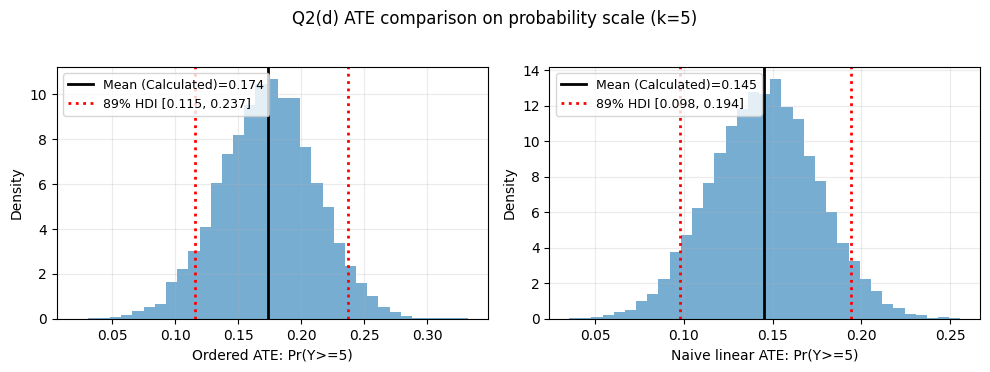

In [106]:
k_plot = 5
ordered_ate_draws = np.asarray(q2b_draws[k_plot]["ate"])
naive_ate_draws = naive_linear_ate_on_exceedance(q2d_samp, year_idx, department, k=k_plot)

plot_posteriors(
    {
        f"Ordered ATE: Pr(Y>={k_plot})": ordered_ate_draws,
        f"Naive linear ATE: Pr(Y>={k_plot})": naive_ate_draws,
    },
    title=f"Q2(d) ATE comparison on probability scale (k={k_plot})",
    ncols=2,
)

## Q3. Wealth, Measurement Error, and Hierarchical Shrinkage

Estimands:
- slope of wealth effect on education (`beta`)
- attenuation bias from naive model
- village-level shrinkage behavior

## EDA

In [103]:
q3.head()

,village,wealth_reported,education_years
0,0,1.7957,7.9145
1,0,0.1017,7.8706
2,0,-0.9673,5.3652
3,0,1.4454,7.7620
4,0,0.6790,8.3506


In [104]:
q3.describe()

,village,wealth_reported,education_years
count,258.000000,258.000000,258.000000
mean,6.941860,-0.026267,5.931721
std,4.297374,1.268010,1.948351
min,0.000000,-3.235900,0.912000
25%,3.000000,-0.960425,4.519275
50%,7.000000,0.007900,5.813200
75%,11.000000,0.885475,7.196550
max,14.000000,3.328300,12.178800


In [105]:
q3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   village          258 non-null    int64  
 1   wealth_reported  258 non-null    float64
 2   education_years  258 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 6.2 KB


## Q3a

In [107]:
village_codes, village_levels = pd.factorize(q3["village"], sort=True)
village = jnp.asarray(village_codes, dtype=jnp.int32)

x_rep = jnp.asarray(q3["wealth_reported"].values, dtype=jnp.float32)
y_edu = jnp.asarray(q3["education_years"].values, dtype=jnp.float32)

n_village = len(village_levels)
sigma_me_known = 0.655

In [108]:
def q3_naive_model(village, x_rep, y, n_village):
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 5.0))
    beta = numpyro.sample("beta", dist.Normal(0.0, 5.0))
    sigma_y = numpyro.sample("sigma_y", dist.Exponential(1.0))

    sigma_village = numpyro.sample("sigma_village", dist.Exponential(1.0))
    with numpyro.plate("plate_village", n_village):
        a_village = numpyro.sample("a_village", dist.Normal(0.0, sigma_village))

    mu = alpha + beta * x_rep + a_village[village]
    with numpyro.plate("data", y.shape[0]):
        numpyro.sample("y_obs", dist.Normal(mu, sigma_y), obs=y)

In [109]:

q3n_mcmc, q3n_idata, q3n_samp = run_mcmc(q3_naive_model, MASTER_KEY, village=village, x_rep=x_rep, y=y_edu, n_village=n_village)

In [115]:
az.summary(q3n_idata, var_names=["alpha", "beta", "sigma_village", "sigma_y", "a_village"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,5.973,0.343,5.410,6.494,0.012,0.009,795.0,1166.0,1.0
beta,0.721,0.065,0.612,0.820,0.001,0.001,7509.0,5372.0,1.0
sigma_village,1.326,0.277,0.914,1.730,0.004,0.003,5909.0,5330.0,1.0
sigma_y,1.291,0.059,1.199,1.388,0.001,0.001,6410.0,5221.0,1.0
a_village[0],0.465,0.439,-0.248,1.154,0.013,0.009,1234.0,2190.0,1.0
a_village[1],-0.195,0.456,-0.924,0.514,0.012,0.009,1354.0,2198.0,1.0
a_village[2],0.728,0.437,0.076,1.468,0.013,0.009,1181.0,2165.0,1.0
a_village[3],-0.902,0.455,-1.605,-0.159,0.012,0.009,1382.0,2677.0,1.0
a_village[4],-0.548,0.445,-1.231,0.180,0.012,0.009,1292.0,2023.0,1.0
a_village[5],0.008,0.426,-0.655,0.705,0.012,0.009,1242.0,2346.0,1.0


In [111]:
# Count divergences
print(f"Divergences: {count_divergences(q3n_idata)}")

Divergences: 0


array([[<Axes: title={'center': 'a_village'}>,
        <Axes: title={'center': 'a_village'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma_village'}>,
        <Axes: title={'center': 'sigma_village'}>],
       [<Axes: title={'center': 'sigma_y'}>,
        <Axes: title={'center': 'sigma_y'}>]], dtype=object)

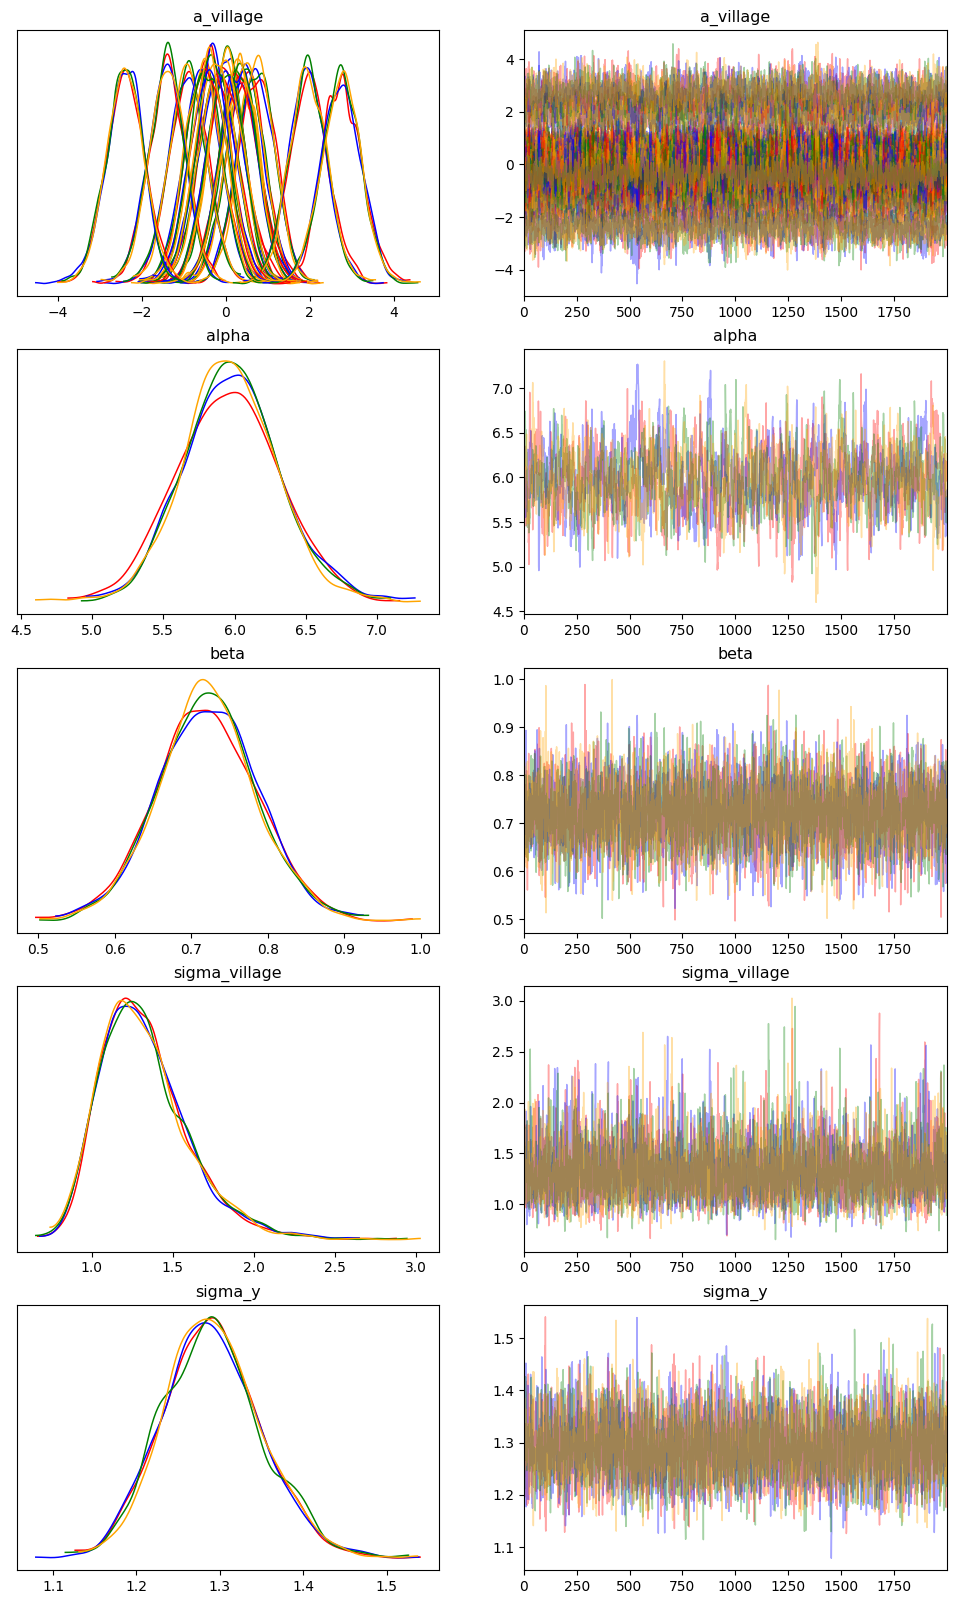

In [112]:
# Plot divergences
az.plot_trace(
        q3n_idata,
        var_names=["~sample_stats"],
        divergences="top", 
        compact=True,
        chain_prop={'color': ['red', 'blue', 'green', 'orange']},
        figsize=(12, 20)
    )


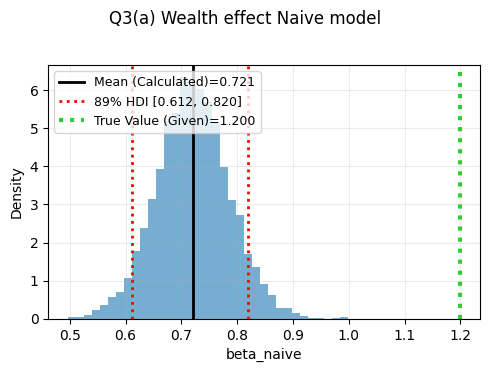

In [116]:
plot_posteriors(
    {"beta_naive": q3n_samp["beta"]},
    title="Q3(a) Wealth effect Naive model",
    ref_values={"beta_naive": 1.2},
    ncols=2,
)

## Q3 (b)

In [ ]:
def q3_me_model(village, x_star, y, n_village=15):
    alpha = numpyro.sample("alpha", dist.Normal(0, 3))
    beta = numpyro.sample("beta", dist.Normal(0, 3))  # informative prior
    sigma_y = numpyro.sample("sigma_y", dist.HalfNormal(1.0))

    sigma_me = numpyro.sample("sigma_me", dist.LogNormal(jnp.log(0.655), 0.1))  # validation-informed

    sigma_village = numpyro.sample("sigma_village", dist.LogNormal(jnp.log(1.5), 0.25))
    with numpyro.plate("plate_village", n_village):
        z_village = numpyro.sample("z_village", dist.Normal(0.0, 1.0))
    a_village = numpyro.deterministic("a_village", z_village * sigma_village)

    with numpyro.plate("data", y.shape[0]):
        x_true = numpyro.sample("x_true", dist.Normal(0.0, 1.0))
        numpyro.sample("x_star_obs", dist.Normal(x_true, sigma_me), obs=x_star)

        mu = alpha + beta * x_true + a_village[village]
        numpyro.sample("y_obs", dist.Normal(mu, sigma_y), obs=y)

In [156]:
# The fixed call for the corrected model
q3c_mcmc, q3c_idata, q3c_samp = run_mcmc(
    q3_me_model, 
    MASTER_KEY, 
    village=village, 
    x_star=x_rep,      # This is the noisy wealth from data
    y=y_edu,           # The outcome
    n_village=n_village, 
    num_warmup=2000,
    num_samples=4000,
    num_chains=4,
    nuts_kwargs={"target_accept_prob": 0.95},
    #sigma_me=0.655     # Crucial: the error SD from the validation study
)

In [150]:
beta_me = np.asarray(q3c_samp["beta"])

In [157]:
az.summary(q3c_idata, var_names=["alpha", "beta", "sigma_village", "sigma_y"], hdi_prob=HDI_PROB)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,5.998,0.343,5.461,6.547,0.006,0.005,2839.0,5961.0,1.0
beta,0.986,0.089,0.841,1.124,0.001,0.001,10897.0,12333.0,1.0
sigma_village,1.297,0.250,0.902,1.658,0.004,0.002,4963.0,8128.0,1.0
sigma_y,1.162,0.070,1.052,1.274,0.001,0.001,9140.0,11554.0,1.0


array([[<Axes: title={'center': 'a_village'}>,
        <Axes: title={'center': 'a_village'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma_village'}>,
        <Axes: title={'center': 'sigma_village'}>],
       [<Axes: title={'center': 'sigma_y'}>,
        <Axes: title={'center': 'sigma_y'}>],
       [<Axes: title={'center': 'x_true'}>,
        <Axes: title={'center': 'x_true'}>],
       [<Axes: title={'center': 'z_village'}>,
        <Axes: title={'center': 'z_village'}>]], dtype=object)

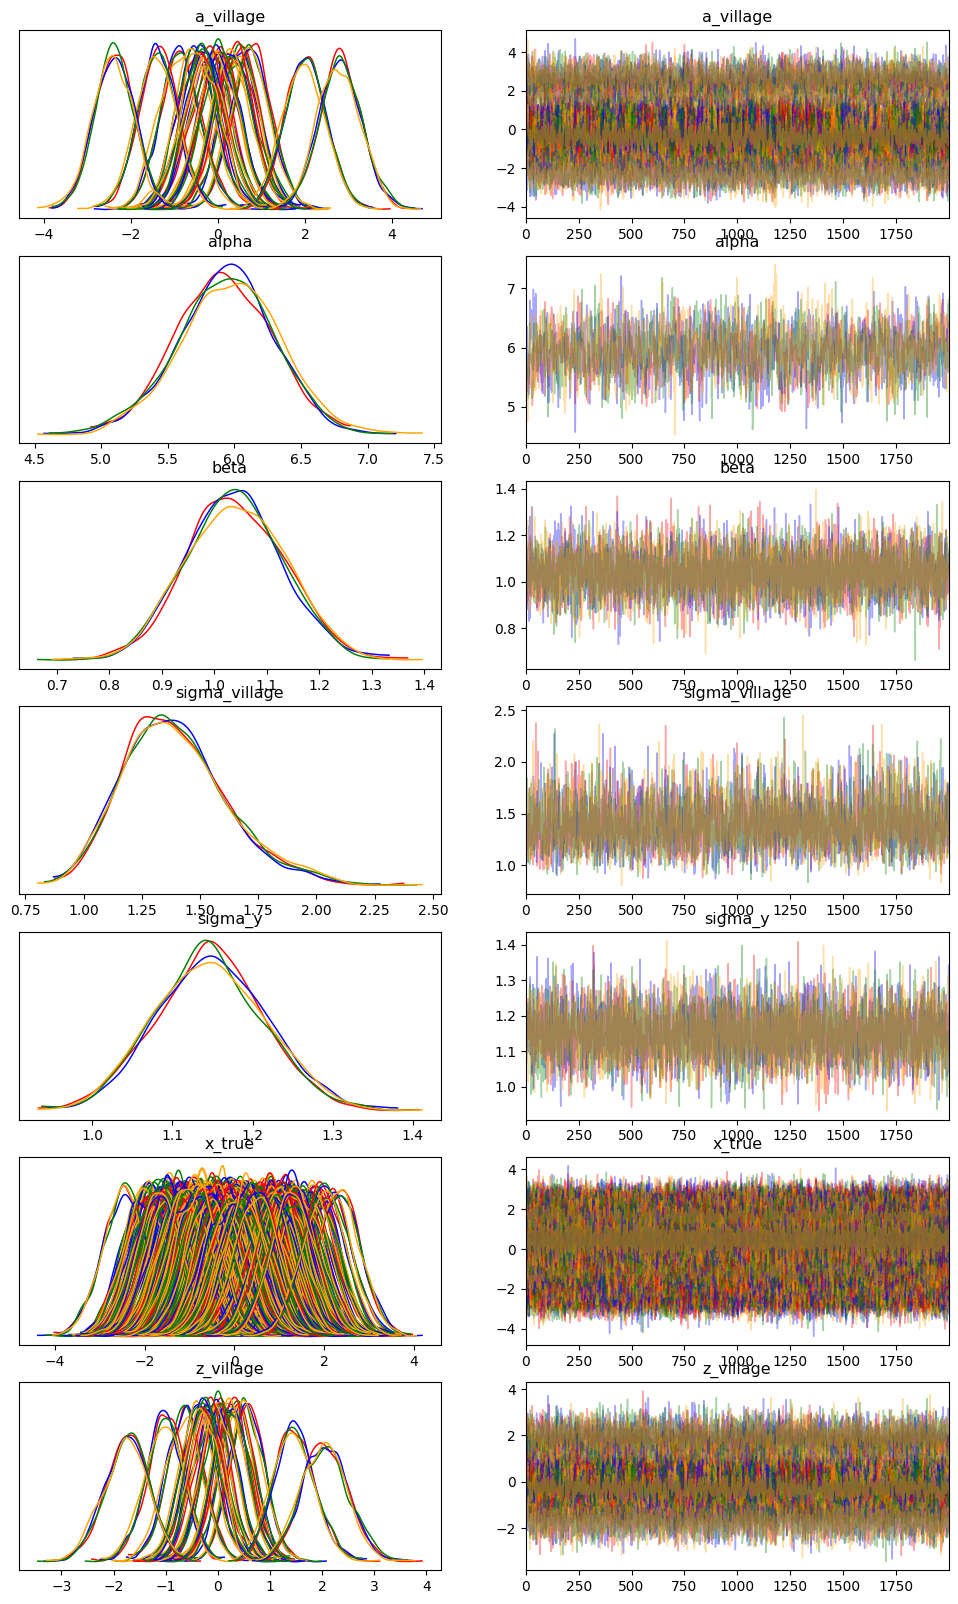

In [121]:
az.plot_trace(
    q3c_idata,
    var_names=["~sample_stats"],
    divergences="top",
    compact=True,
    figsize=(12, 20),
    chain_prop={'color': ['red', 'blue', 'green', 'orange']},
)

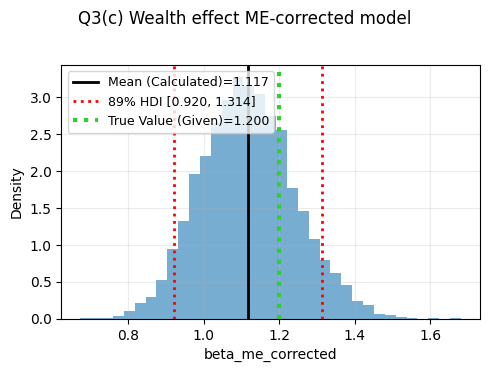

In [147]:
plot_posteriors(
    {"beta_me_corrected": beta_me},
    title="Q3(c) Wealth effect ME-corrected model",
    ref_values={"beta_me_corrected": 1.2},
    ncols=2,
)

## Q3(c)

In [ ]:
# Q3(d) Shrinkage visualization (preferred: ME model)
alpha_hat = float(np.mean(np.asarray(q3m_samp["alpha"])))
a_v_hat = np.mean(np.asarray(q3m_samp["sigma_v"])[:, None] * np.asarray(q3m_samp["z_v"]), axis=0)
pooled_intercepts = alpha_hat + a_v_hat

raw_village_means = q3.groupby("village")["education_years"].mean().values
grand_mean = q3["education_years"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(raw_village_means, pooled_intercepts, s=55)
lo = min(raw_village_means.min(), pooled_intercepts.min())
hi = max(raw_village_means.max(), pooled_intercepts.max())
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_title("Q3(d) Raw village means vs partial-pooling intercepts")
axes[0].set_xlabel("Raw village mean (unpooled)")
axes[0].set_ylabel("Hierarchical intercept estimate")
axes[0].grid(alpha=0.2)

raw_dev = np.abs(raw_village_means - grand_mean)
pool_dev = np.abs(pooled_intercepts - grand_mean)
shrink_amount = raw_dev - pool_dev
axes[1].bar(np.arange(len(shrink_amount)), shrink_amount)
axes[1].set_title("Q3(d) Shrinkage toward grand mean by village")
axes[1].set_xlabel("Village")
axes[1].set_ylabel("Shrinkage amount")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

most_shrunk = np.argsort(shrink_amount)[-3:][::-1]
print("Most shrunk villages:", most_shrunk.tolist())

## Q4. Exercise, Depression, and Missing Mediator Data

In [ ]:
q4.head()

In [ ]:
q4.describe()

In [ ]:
q4.info()

In [ ]:

clinic = jnp.asarray(q4["clinic"].values.astype(int))
trt = jnp.asarray(q4["treatment"].values.astype(float))
y_dep = jnp.asarray(q4["depression"].values.astype(float))

mA = jnp.asarray(pd.to_numeric(q4["engagement_A"], errors="coerce").values)
mB = jnp.asarray(pd.to_numeric(q4["engagement_B"], errors="coerce").values)

n_clinic = int(q4["clinic"].max() + 1)

In [ ]:
def q4_total_effect_model(clinic, trt, y, n_clinic=8):
    alpha = numpyro.sample("alpha", dist.Normal(20, 5))
    beta_total = numpyro.sample("beta_total", dist.Normal(0, 3))
    sigma_c = numpyro.sample("sigma_c", dist.HalfNormal(3))
    z_c = numpyro.sample("z_c", dist.Normal(0, 1).expand([n_clinic]))
    a_c = sigma_c * z_c
    sigma_y = numpyro.sample("sigma_y", dist.HalfNormal(5))

    mu = alpha + beta_total * trt + a_c[clinic]
    numpyro.sample("Y_obs", dist.Normal(mu, sigma_y), obs=y)

In [ ]:
k_q4_total = random.PRNGKey(404)
q4t_mcmc, q4t_idata, q4t_samp = run_mcmc(q4_total_effect_model, k_q4_total, clinic=clinic, trt=trt, y=y_dep, n_clinic=n_clinic)

In [ ]:
az.summary(q4t_idata, var_names=["alpha", "beta_total", "sigma_c", "sigma_y"], hdi_prob=HDI_PROB)

In [ ]:
plot_posteriors(
    {
        "q4t_mcmc": np.asarray(q4t_samp["beta_total"]),
    },
    title="Q4(b) Total effect model",
    ref_values={"q4t_mcmc": -3.0},
)

In [ ]:
# ------------------------------
# Q4(b,c,d): total effect + decomposition under A and B
# ------------------------------






def q4_mediation_mar_style_model(clinic, trt, m_obs, y, n_clinic=8):
    alpha = numpyro.sample("alpha", dist.Normal(20, 5))
    beta_direct = numpyro.sample("beta_direct", dist.Normal(0, 3))
    delta = numpyro.sample("delta", dist.Normal(0, 3))
    lambda_m = numpyro.sample("lambda_m", dist.Normal(0, 3))

    sigma_c = numpyro.sample("sigma_c", dist.HalfNormal(3))
    z_c = numpyro.sample("z_c", dist.Normal(0, 1).expand([n_clinic]))
    a_c = sigma_c * z_c

    sigma_m = numpyro.sample("sigma_m", dist.HalfNormal(3))
    sigma_y = numpyro.sample("sigma_y", dist.HalfNormal(5))

    mask = ~jnp.isnan(m_obs)
    m_filled = jnp.where(mask, m_obs, 0.0)

    mu_m = delta * trt
    m_all = numpyro.sample("m_all", dist.Normal(mu_m, sigma_m))
    numpyro.sample("M_obs", dist.Normal(m_all, 1e-3).mask(mask), obs=m_filled)

    mu_y = alpha + beta_direct * trt + lambda_m * m_all + a_c[clinic]
    numpyro.sample("Y_obs", dist.Normal(mu_y, sigma_y), obs=y)

    numpyro.deterministic("beta_indirect", delta * lambda_m)
    numpyro.deterministic("beta_total", beta_direct + delta * lambda_m)


# (b) total effect model
q4t_sum = 
print_fit_report("Q4(b) Total effect model", q4t_idata, q4t_sum)
print(hdi_text(np.asarray(q4t_samp["beta_total"]), "Q4 total effect"))

# (c) Scenario A decomposition (MAR)
k_q4_A = random.PRNGKey(405)
q4a_mcmc, q4a_idata, q4a_samp = run_mcmc(
    q4_mediation_mar_style_model,
    k_q4_A,
    clinic=clinic,
    trt=trt,
    m_obs=mA,
    y=y_dep,
    n_clinic=n_clinic,
)
q4a_sum = az.summary(q4a_idata, var_names=["beta_direct", "delta", "lambda_m", "beta_indirect", "beta_total"], hdi_prob=HDI_PROB)
print_fit_report("Q4(c) Scenario A decomposition", q4a_idata, q4a_sum)

# (d) Scenario B with same MAR-style model (expected bias under MNAR)
k_q4_B = random.PRNGKey(406)
q4b_mcmc, q4b_idata, q4b_samp = run_mcmc(
    q4_mediation_mar_style_model,
    k_q4_B,
    clinic=clinic,
    trt=trt,
    m_obs=mB,
    y=y_dep,
    n_clinic=n_clinic,
)
q4b_sum = az.summary(q4b_idata, var_names=["beta_direct", "delta", "lambda_m", "beta_indirect", "beta_total"], hdi_prob=HDI_PROB)
print_fit_report("Q4(d) Scenario B decomposition with MAR-style fit", q4b_idata, q4b_sum)

plot_posteriors(
    {
        "A_beta_direct": np.asarray(q4a_samp["beta_direct"]),
        "A_beta_indirect": np.asarray(q4a_samp["beta_indirect"]),
        "A_beta_total": np.asarray(q4a_samp["beta_total"]),
    },
    title="Q4(c) Scenario A effects",
    ref_values={"A_beta_direct": -1.5, "A_beta_indirect": -1.5, "A_beta_total": -3.0},
)

plot_posteriors(
    {
        "B_beta_direct": np.asarray(q4b_samp["beta_direct"]),
        "B_beta_indirect": np.asarray(q4b_samp["beta_indirect"]),
        "B_beta_total": np.asarray(q4b_samp["beta_total"]),
    },
    title="Q4(d) Scenario B effects (MAR-style analysis under MNAR)",
)

## Q5. Broadband, Spatial Correlation, and Heterogeneous Effects

Estimands:
- broadband effect under naive and spatial models
- urban vs rural heterogeneous broadband effects
- ATE on patent-count scale for +0.10 broadband

In [ ]:
q5.head()

In [ ]:
q5.describe()

In [ ]:
q5.info()

In [ ]:
# ------------------------------
# Q5(a,b,c,d): Poisson + GP spatial + heterogeneity + count-scale ATE
# ------------------------------

coords = q5[["coord_x", "coord_y"]].values.astype(float)
region_type = jnp.asarray(q5["region_type"].values.astype(int))
broadband = jnp.asarray(q5["broadband"].values.astype(float))
population = jnp.asarray(q5["population"].values.astype(float))
patents = jnp.asarray(q5["patents"].values.astype(int))

log_pop = jnp.log(population)

d2 = np.sum((coords[:, None, :] - coords[None, :, :]) ** 2, axis=-1)
d2_jnp = jnp.asarray(d2)


def q5_naive_poisson_model(x, log_pop, y=None):
    alpha = numpyro.sample("alpha", dist.Normal(-7, 2))
    beta = numpyro.sample("beta", dist.Normal(0, 3))
    log_mu = alpha + beta * x + log_pop
    numpyro.sample("Y_obs", dist.Poisson(jnp.exp(log_mu)), obs=y)


def q5_spatial_poisson_model(x, log_pop, d2, y=None):
    alpha = numpyro.sample("alpha", dist.Normal(-7, 2))
    beta = numpyro.sample("beta", dist.Normal(0, 3))
    eta = numpyro.sample("eta", dist.HalfNormal(1.5))
    rho = numpyro.sample("rho", dist.HalfNormal(3.0))

    K = (eta ** 2) * jnp.exp(-(rho ** 2) * d2) + 0.01 * jnp.eye(d2.shape[0])
    k = numpyro.sample("k", dist.MultivariateNormal(loc=jnp.zeros(d2.shape[0]), covariance_matrix=K))

    log_mu = alpha + beta * x + k + log_pop
    numpyro.sample("Y_obs", dist.Poisson(jnp.exp(log_mu)), obs=y)


def q5_spatial_hetero_model(x, region_type, log_pop, d2, y=None):
    alpha = numpyro.sample("alpha", dist.Normal(-7, 2))
    beta_urban = numpyro.sample("beta_urban", dist.Normal(0, 3))
    beta_rural = numpyro.sample("beta_rural", dist.Normal(0, 3))
    eta = numpyro.sample("eta", dist.HalfNormal(1.5))
    rho = numpyro.sample("rho", dist.HalfNormal(3.0))

    beta = jnp.where(region_type == 0, beta_urban, beta_rural)

    K = (eta ** 2) * jnp.exp(-(rho ** 2) * d2) + 0.01 * jnp.eye(d2.shape[0])
    k = numpyro.sample("k", dist.MultivariateNormal(loc=jnp.zeros(d2.shape[0]), covariance_matrix=K))

    log_mu = alpha + beta * x + k + log_pop
    numpyro.sample("Y_obs", dist.Poisson(jnp.exp(log_mu)), obs=y)

q5a_mcmc, q5a_idata, q5a_samp = run_mcmc(q5_naive_poisson_model, MASTER_KEY, x=broadband, log_pop=log_pop, y=patents)
q5b_mcmc, q5b_idata, q5b_samp = run_mcmc(q5_spatial_poisson_model, MASTER_KEY, x=broadband, log_pop=log_pop, d2=d2_jnp, y=patents)
q5c_mcmc, q5c_idata, q5c_samp = run_mcmc(q5_spatial_hetero_model, MASTER_KEY, x=broadband, region_type=region_type, log_pop=log_pop, d2=d2_jnp, y=patents)

q5a_sum = az.summary(q5a_idata, var_names=["alpha", "beta"], hdi_prob=HDI_PROB)
q5b_sum = az.summary(q5b_idata, var_names=["alpha", "beta", "eta", "rho"], hdi_prob=HDI_PROB)
q5c_sum = az.summary(q5c_idata, var_names=["alpha", "beta_urban", "beta_rural", "eta", "rho"], hdi_prob=HDI_PROB)

print_fit_report("Q5(a) Naive Poisson", q5a_idata, q5a_sum)
print_fit_report("Q5(b) Spatial Poisson", q5b_idata, q5b_sum)
print_fit_report("Q5(c) Spatial heterogeneous model", q5c_idata, q5c_sum)

plot_posteriors(
    {
        "naive_beta": q5a_samp["beta"],
        "spatial_beta": q5b_samp["beta"],
        "beta_urban": q5c_samp["beta_urban"],
        "beta_rural": q5c_samp["beta_rural"],
    },
    title="Q5 broadband effects (89% HDI)",
    ref_values={"beta_urban": 2.0, "beta_rural": 1.5},
)

# Residual spatial pattern for naive model
alpha_naive = np.mean(np.asarray(q5a_samp["alpha"]))
beta_naive = np.mean(np.asarray(q5a_samp["beta"]))
mu_naive = np.exp(alpha_naive + beta_naive * q5["broadband"].values + np.log(q5["population"].values))
pearson_resid = (q5["patents"].values - mu_naive) / np.sqrt(np.maximum(mu_naive, 1e-6))

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(q5["coord_x"], q5["coord_y"], c=pearson_resid, s=120, cmap="coolwarm")
for i, rid in enumerate(q5["region_id"].values):
    ax.text(q5["coord_x"].values[i] + 0.01, q5["coord_y"].values[i] + 0.01, str(rid), fontsize=8)
ax.set_title("Q5(a) Naive-model Pearson residuals by region")
ax.set_xlabel("coord_x")
ax.set_ylabel("coord_y")
ax.grid(alpha=0.2)
plt.colorbar(sc, ax=ax, label="Pearson residual")
plt.tight_layout()
plt.show()

# Q5(d) ATE on count scale for +0.10 broadband using spatial hetero model
alpha_draw = np.asarray(q5c_samp["alpha"])
beta_u_draw = np.asarray(q5c_samp["beta_urban"])
beta_r_draw = np.asarray(q5c_samp["beta_rural"])
k_draw = np.asarray(q5c_samp["k"])

ate_draws = []
naive_backtrans_draws = []
for d in range(len(alpha_draw)):
    beta_region = np.where(q5["region_type"].values == 0, beta_u_draw[d], beta_r_draw[d])

    log_mu0 = alpha_draw[d] + beta_region * q5["broadband"].values + k_draw[d] + np.log(q5["population"].values)
    log_mu1 = alpha_draw[d] + beta_region * (q5["broadband"].values + 0.10) + k_draw[d] + np.log(q5["population"].values)

    mu0 = np.exp(log_mu0)
    mu1 = np.exp(log_mu1)

    ate_draws.append(float(np.mean(mu1 - mu0)))

    beta_avg = np.mean(beta_region)
    naive_backtrans_draws.append(float(np.mean(mu0) * (np.exp(0.10 * beta_avg) - 1.0)))

ate_draws = np.asarray(ate_draws)
naive_backtrans_draws = np.asarray(naive_backtrans_draws)

print(hdi_text(ate_draws, "Q5(d) Count-scale ATE (+0.10 broadband)"))
print(hdi_text(naive_backtrans_draws, "Naive back-transform approximation"))
print(hdi_text(ate_draws - naive_backtrans_draws, "Difference (marginalized - naive)"))

### Divergence diagnostics (Q1 models)